# 06 — DOMINANT vs GAD-NR: Grafo de Grupos (G)

Este notebook entrena y compara dos detectores de anomalías sobre el grafo de grupos `G`
usando la librería **PyGOD 1.1.0**, replicando la metodología del notebook 05 (grafo M)
adaptada al grafo de grupos.

- **DOMINANT** (Ding et al., SDM 2019): línea base consolidada en la literatura — encoder GCN
  compartido con dos decoders que reconstruyen estructura y atributos por separado.
- **GAD-NR** (Roy et al., WSDM 2024): estado del arte en la familia GNN+AE — reconstruye el
  vecindario completo de cada nodo (features propias, grado y distribución de atributos de vecinos).

## Diferencias clave respecto al grafo M

| Aspecto | Grafo M | Grafo G |
|---|---|---|
| Nodos | 11.371 miembros | 456 grupos |
| Aristas únicas | 1.176.024 | 6.692 |
| Features/nodo | 3 (geográficas) | 35 (size, activity, category one-hot) |
| Densidad | 0.018 (disperso) | 0.065 (×4 más denso) |
| Grado medio | 207 | 29 |

El grafo G es **mucho más pequeño y con muchas más features que el grafo M**. Esta diferencia es
relevante porque el comportamiento del curriculum de GAD-NR observado en el grafo M (sección 4.1
del notebook 05) está condicionado por la asimetría entre la escala del loss de grado (rango
0-2356) y la de features (3 dimensiones con poca varianza). En G la asimetría es menor y se
espera un comportamiento del curriculum distinto.

## Esquema del notebook

| Sección | Contenido |
|---------|-----------|
| 0 | Imports y configuración |
| 1 | Carga del grafo G |
| 2 | Fundamento teórico: DOMINANT y GAD-NR |
| 3 | Entrenamiento de DOMINANT |
| 4 | Entrenamiento de GAD-NR |
| 5 | Consenso final y tipología de anomalías |
| 6 | Spotlight — candidatos del EDA |
| 7 | Comparativa DOMINANT vs GAD-NR |
| 8 | Visualización t-SNE de los embeddings |
| 9 | Guardado de resultados |


## 0. Imports y configuración

In [1]:
%matplotlib inline

import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from pygod.detector import DOMINANT, GADNR
from scipy.stats import rankdata, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.insert(0, '..')
from src.utils.visualization import (
    apply_theme, polish, save_figure,
    PALETTE, CAT_COLORS, CMAP_SEQ, CMAP_HEAT,
    FS, FONT,
)
apply_theme()

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_idx = 0 if torch.cuda.is_available() else -1
print(f'Device : {device}')
print(f'PyGOD  : DOMINANT y GADNR importados correctamente')

c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyGOD  : DOMINANT y GADNR importados correctamente


## 1. Carga del grafo G

Cargamos el objeto `Data` del grafo G generado en el notebook `04_feature_engineering.ipynb`.
Tanto DOMINANT como GAD-NR usan el grafo completo durante el entrenamiento — no hacen split
de aristas porque son modelos de detección de anomalías no supervisados, no de predicción de
enlaces. Necesitan ver toda la estructura para aprender el patrón normal.

PyGOD requiere un objeto `Data` con solo `x` y `edge_index` — los atributos adicionales
como `group_ids` o `edge_weight` deben eliminarse para evitar errores de conversión.


In [2]:
data_G = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_G.pt'), weights_only=False)
print(data_G)
print(f'\nNodos          : {data_G.num_nodes}')
print(f'Aristas únicas : {data_G.num_edges // 2}')
print(f'Features/nodo  : {data_G.num_node_features}')

# Guardamos los IDs originales antes de limpiar el objeto Data
group_ids = data_G.group_ids  # lista de group_id en el mismo orden que los nodos

# Objeto limpio para PyGOD — solo x y edge_index
data_G_clean = Data(
    x=data_G.x,
    edge_index=data_G.edge_index,
)
print(f'\ndata_G_clean: {data_G_clean}')


Data(x=[456, 35], edge_index=[2, 13384], edge_weight=[13384], group_ids=[456])

Nodos          : 456
Aristas únicas : 6692
Features/nodo  : 35

data_G_clean: Data(x=[456, 35], edge_index=[2, 13384])


In [3]:
# Metadatos de grupos para interpretar resultados
meta_groups = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-groups.csv'))

# DataFrame base indexado por group_id — se enriquecerá con los scores
id_to_idx = {gid: i for i, gid in enumerate(group_ids)}
base_df = pd.DataFrame({'group_id': group_ids})
base_df['idx'] = base_df.index
base_df = base_df.merge(
    meta_groups[['group_id', 'group_name', 'category_name', 'num_members', 'organizer_id']],
    on='group_id', how='left'
)
# Renombramos group_name a 'name' para mantener la convención del notebook 05
base_df = base_df.rename(columns={'group_name': 'name'})

# Grado de cada nodo (aristas únicas / 2 porque el grafo es no dirigido y duplicado)
edge_src = data_G.edge_index[0].numpy()
degree = np.bincount(edge_src, minlength=data_G.num_nodes) // 2  # cada arista aparece dos veces
base_df['degree'] = degree

print(f'base_df: {base_df.shape}')
base_df.head()


base_df: (456, 7)


,group_id,idx,name,category_name,num_members,organizer_id,degree
0,339011,0,Nashville Hiking Meetup,Outdoors & Adventure,15838,4353803,68
1,19728145,1,Stepping Out Social Dance Meetup,Dancing,1778,118484462,91
2,6335372,2,Nashville soccer,Sports & Recreation,2869,108448302,29
3,10016242,3,NashJS,Tech,1975,8111102,53
4,21174496,4,20's & 30's Women looking for girlfriends,Socializing,2782,184580248,38


## 2. Fundamento teórico: DOMINANT y GAD-NR

El fundamento teórico de ambos modelos es idéntico al descrito en el notebook 05 (grafo M).
Se repite aquí brevemente para que este notebook sea autocontenido.

### 2.1 DOMINANT (Ding et al., SDM 2019)

DOMINANT extiende el GAE estándar con un segundo decoder. Tiene tres componentes:

**Encoder GCN compartido.** Produce embeddings latentes $Z$ combinando features $X$ y estructura $A$:
$$Z = \text{GCN}(X, A)$$

**Decoder de estructura.** Producto interno con sigmoide — idéntico al GAE clásico:
$$\hat{A}_{ij} = \sigma(z_i^T z_j)$$

**Decoder de atributos.** Una GCN que reconstruye la matriz de features original desde los embeddings:
$$\hat{X} = \text{GCN}(Z, A)$$

La función de pérdida combina los dos errores de reconstrucción ponderados por `weight` $\in [0, 1]$:
$$\mathcal{L} = (1 - w) \cdot \|A - \hat{A}\|_F^2 + w \cdot \|X - \hat{X}\|_F^2$$

El anomaly score de cada nodo se calcula de forma análoga:
$$s_i = (1 - w) \cdot s_i^{struct} + w \cdot s_i^{attr}$$

En este notebook tratamos $s_i^{struct}$ y $s_i^{attr}$ como **señales independientes**
para mantener la distinción entre anomalía estructural y de atributo.

### 2.2 GAD-NR (Roy et al., WSDM 2024)

GAD-NR reconstruye el **vecindario completo** de cada nodo, capturando tres dimensiones:

**Reconstrucción de features propias.** Error entre las features reales del nodo y su reconstrucción:
$$\mathcal{L}_{feat} = \|x_i - \hat{x}_i\|^2$$

**Reconstrucción de grado.** Error entre el grado real y el grado predicho por un decoder MLP:
$$\mathcal{L}_{deg} = \text{CrossEntropy}(d_i, \hat{d}_i)$$

**Reconstrucción de la distribución de vecinos.** Divergencia KL entre la distribución real
de features de los vecinos y la distribución reconstruida (modelada como Gaussiana):
$$\mathcal{L}_{neigh} = D_{KL}(p_{neigh}(x) \| q_{neigh}(z))$$

### 2.3 Hiperparámetros para el grafo G

Los hiperparámetros se han ajustado al menor tamaño del grafo G (456 nodos vs 11.371 de M)
y a su mayor dimensionalidad de features (35 vs 3). Los cambios principales son:

| Hiperparámetro | Grafo M | Grafo G | Motivo |
|---|---|---|---|
| `hid_dim` | 64 | 32 | Grafo más pequeño, menos riesgo de underfit con dim menor |
| `epoch` | 300 | 300 | Sin cambio — convergencia full-batch rápida |
| `dropout` (GADNR) | 0.1 | 0.2 | Más regularización con menos datos |
| `weight` (DOM) | 0.2 | 0.5 | Más peso a atributos: en G tenemos 35 features ricas |


## 3. Entrenamiento de DOMINANT

Configuración análoga al notebook 05 con los ajustes documentados en la sección 2.3:
`hid_dim` reducido a 32 (grafo pequeño) y `weight=0.5` (balance equilibrado entre estructura
y atributos, ya que ahora tenemos 35 features ricas).


In [4]:
dominant = DOMINANT(
    hid_dim=64,
    num_layers=4,       # 2 capas encoder + 2 capas decoder
    dropout=0.0,
    weight_decay=0.0,
    act=F.relu,
    sigmoid_s=False,
    weight=0.6,         # peso del error de atributo: equilibrado porque G tiene 35 features ricas
    contamination=0.05, # P95 — 5% de anomalías
    lr=0.004,
    epoch=300,
    gpu=gpu_idx,
    batch_size=0,       # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando DOMINANT sobre el grafo G...')
dominant.fit(data_G_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {dominant.decision_score_.shape}')
print(f'  min={dominant.decision_score_.min():.4f}, '
      f'max={dominant.decision_score_.max():.4f}, '
      f'mean={dominant.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {dominant.label_.sum().item()} '
      f'({dominant.label_.float().mean().item():.1%})')


Entrenando DOMINANT sobre el grafo G...
Epoch 0000: Loss 8.3598 |  | Time 0.25
Epoch 0001: Loss 3.6176 |  | Time 0.01
Epoch 0002: Loss 2.7682 |  | Time 0.01
Epoch 0003: Loss 2.7627 |  | Time 0.01
Epoch 0004: Loss 2.8619 |  | Time 0.01
Epoch 0005: Loss 2.9577 |  | Time 0.01
Epoch 0006: Loss 2.9021 |  | Time 0.02
Epoch 0007: Loss 2.8119 |  | Time 0.01
Epoch 0008: Loss 2.7600 |  | Time 0.01
Epoch 0009: Loss 2.7369 |  | Time 0.01
Epoch 0010: Loss 2.7225 |  | Time 0.01
Epoch 0011: Loss 2.7075 |  | Time 0.01
Epoch 0012: Loss 2.6896 |  | Time 0.01
Epoch 0013: Loss 2.6705 |  | Time 0.01
Epoch 0014: Loss 2.6528 |  | Time 0.01
Epoch 0015: Loss 2.6382 |  | Time 0.01
Epoch 0016: Loss 2.6252 |  | Time 0.01
Epoch 0017: Loss 2.6108 |  | Time 0.01
Epoch 0018: Loss 2.5961 |  | Time 0.01
Epoch 0019: Loss 2.5845 |  | Time 0.01
Epoch 0020: Loss 2.5773 |  | Time 0.02
Epoch 0021: Loss 2.5724 |  | Time 0.01
Epoch 0022: Loss 2.5669 |  | Time 0.01
Epoch 0023: Loss 2.5598 |  | Time 0.01
Epoch 0024: Loss 2.5523 

In [5]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """
    Extrae los scores de estructura y atributo de DOMINANT.
    
    double_recon_loss calcula:
      attr_error   = sqrt(sum((x - x_)^2, dim=1))
      struct_error = sqrt(sum((s - s_)^2, dim=1))
      score = weight * attr_error + (1 - weight) * struct_error
    """
    model = detector.model
    model.eval()

    data_proc = data.clone()
    model.process_graph(data_proc)  # añade data_proc.s (adyacencia densa)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)

    x_hat, s_hat = model(x, edge_index)

    # RMSE por nodo — igual que double_recon_loss
    attr_scores   = torch.sqrt(torch.sum((x - x_hat) ** 2, dim=1)).cpu().numpy()
    struct_scores = torch.sqrt(torch.sum((s_real - s_hat) ** 2, dim=1)).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_G_clean)

print(f'DOM struct — min={dom_struct.min():.4f}, max={dom_struct.max():.4f}, mean={dom_struct.mean():.4f}')
print(f'DOM attr   — min={dom_attr.min():.4f},  max={dom_attr.max():.4f},  mean={dom_attr.mean():.4f}')

# Verificación: score = weight*attr + (1-weight)*struct
score_check = dominant.weight * dom_attr + (1 - dominant.weight) * dom_struct
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')


DOM struct — min=0.9074, max=8.9188, mean=3.8315
DOM attr   — min=0.1390,  max=2.9799,  mean=1.1359

Verificación — correlación con decision_score_: 0.991426
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_score_distribution_G.png


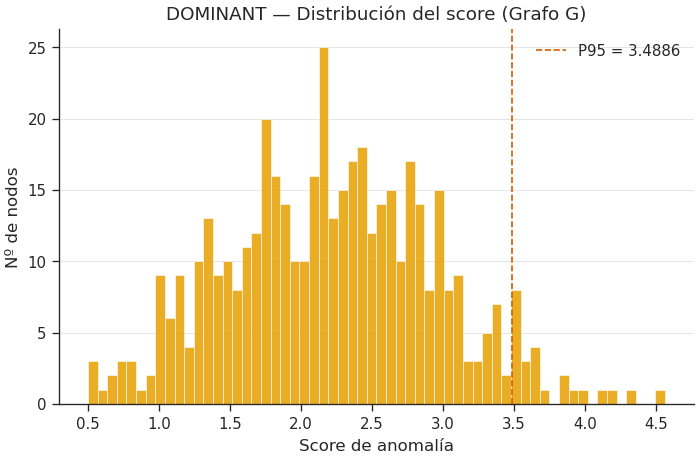

In [6]:
# Distribución del score de DOMINANT
dom_score = dominant.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(dom_score, bins=60, color=PALETTE['G'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(dom_score, 95)
ax.axvline(p95_dom, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — Distribución del score (Grafo G)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '06_dominant_score_distribution_G.png')
plt.show()


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_score_distributions_G.png


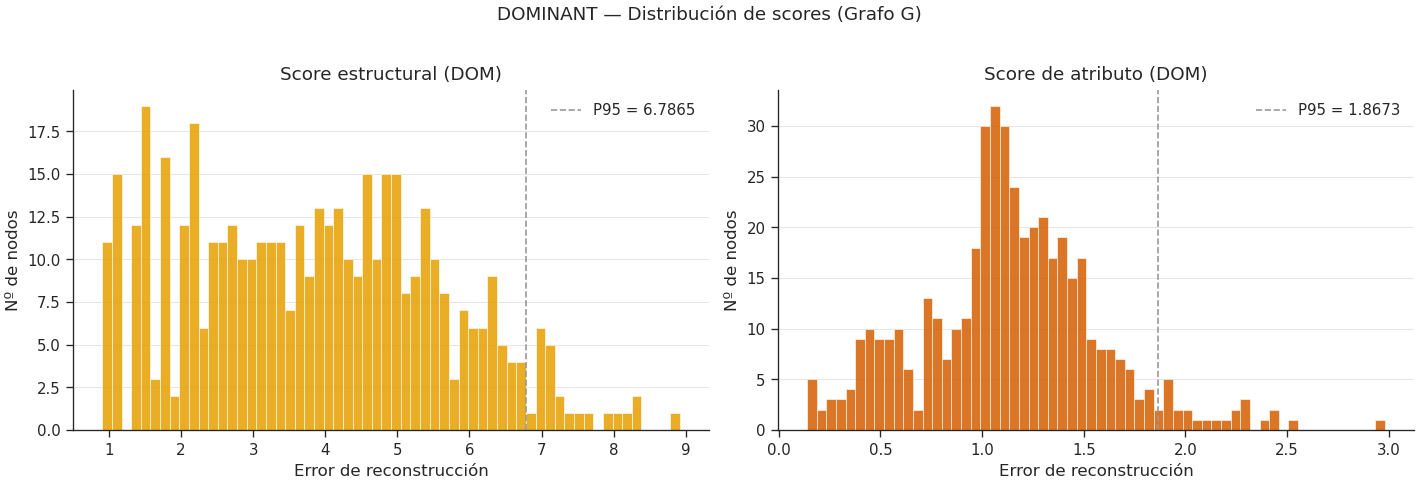

Correlación Spearman struct vs attr (DOMINANT): ρ = -0.0249


In [7]:
# Distribuciones de los dos scores de DOMINANT
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, scores, label, color in zip(
    axes,
    [dom_struct, dom_attr],
    ['Score estructural (DOM)', 'Score de atributo (DOM)'],
    [PALETTE['G'], PALETTE['anomaly']]
):
    ax.hist(scores, bins=60, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['neutral'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.4f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(label, fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.suptitle('DOMINANT — Distribución de scores (Grafo G)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '06_dominant_score_distributions_G.png')
plt.show()

rho_dom, _ = spearmanr(dom_struct, dom_attr)
print(f'Correlación Spearman struct vs attr (DOMINANT): ρ = {rho_dom:.4f}')


## 4. Entrenamiento de GAD-NR

Aplicamos el mismo modelo GAD-NR que en el grafo M, con los workarounds documentados en el
notebook 05 (parches para bugs de PyGOD 1.1.0 con GPU y `tot_nodes`).

**Hipótesis sobre el curriculum en este grafo.** En el grafo M se observó que el mecanismo
interno de re-ponderación de lambdas de GAD-NR colapsaba la pérdida de grado y amplificaba la
de features, debido a la fuerte asimetría entre la escala del loss de grado (rango 0-2356) y la
de features (3 dimensiones con poca varianza). En el grafo G la situación es distinta: el
rango de grados es menor (0-182) y hay muchas más features (35), por lo que se espera un
comportamiento del curriculum más equilibrado. La sección 4.1 documentará lo observado tras
el entrenamiento.


In [8]:
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase
import pygod.detector.gadnr as _gadnr_module
# ── Workaround bug PyGOD 1.1.0 ──────────────────────────────────────────────
# tot_nodes se pasa al backbone GCN a través de **kwargs, pero GCNConv
# (PyG >= 2.5) ya no acepta ese argumento en MessagePassing.__init__().
# Parche: sobreescribimos init_model para filtrar tot_nodes antes del forward.
def _patched_init_model(self, **kwargs):
    kwargs.pop('tot_nodes', None)   # eliminar el argumento problemático
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

GADNR.init_model = _patched_init_model
# ────────────────────────────────────────────────────────────────────────────


In [9]:
import torch
import torch.nn.functional as F
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase

# ── Workaround doble bug PyGOD 1.1.0 con GAD-NR en GPU ──────────────────────
# Bug 1: tot_nodes se pasa al backbone GCN que no lo acepta
# Bug 2: GADNRBase recibe device como string desde self.device pero algunos
#        tensores internos (neighbor_num_list en loss_func) se quedan en CPU
def _patched_init_model(self, **kwargs):
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,  # ya está en self.device
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,         # device correcto — cuda:0
    ).to(self.device)

def _patched_forward_model(self, data):
    # Aseguramos que todos los tensores de entrada están en el device correcto
    data.x = data.x.to(self.device)
    data.edge_index = data.edge_index.to(self.device)
    self.neighbor_num_list = self.neighbor_num_list.to(self.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        self.model(data.x, data.edge_index)

    loss, loss_per_node, h_loss, degree_loss, feature_loss = \
        self.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, self.neighbor_num_list
        )

    return (loss,
            loss_per_node.cpu().detach(),
            h_loss.cpu().detach(),
            degree_loss.cpu().detach(),
            feature_loss.cpu().detach())

GADNR.init_model    = _patched_init_model
GADNR.forward_model = _patched_forward_model

In [10]:
# ──────────────────────────────────────────────────────────────────────────
# Configuración de GAD-NR para el grafo G
# ──────────────────────────────────────────────────────────────────────────
# Mismos hiperparámetros que en el grafo M salvo:
#   • hid_dim=32 (grafo más pequeño, 456 nodos)
#   • dropout=0.2 (más regularización con menos datos)
#   • lambda_lossN — iniciales sin reescalado manual, dejamos que el
#     mecanismo interno los ajuste y documentamos el comportamiento
#     en la sección 4.1.
# ──────────────────────────────────────────────────────────────────────────

gadnr = GADNR(
    hid_dim=64,
    num_layers=1,           # capas del encoder GNN — 1 según el paper
    deg_dec_layers=4,
    fea_dec_layers=3,
    sample_size=4,
    sample_time=5,
    neigh_loss='KL',
    lambda_loss1=1e-4,   # vecindario
    lambda_loss2=1e-2,   # features ← prioritario
    lambda_loss3=1e-3,   # grado
    real_loss=True,
    contamination=0.05,
    lr=0.004,
    epoch=300,
    dropout=0,           
    weight_decay=1e-3,
    act=F.relu,
    gpu=gpu_idx,
    batch_size=0,
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando GAD-NR sobre el grafo G...')
gadnr.fit(data_G_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {gadnr.decision_score_.shape}')
print(f'  min={gadnr.decision_score_.min():.4f}, '
      f'max={gadnr.decision_score_.max():.4f}, '
      f'mean={gadnr.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {gadnr.label_.sum().item()} '
      f'({gadnr.label_.float().mean().item():.1%})')



Entrenando GAD-NR sobre el grafo G...
Epoch 0001: Loss 1.9595 |  | Time 0.20
Epoch 0002: Loss 1.9595 |  | Time 0.08
Epoch 0003: Loss 1.9594 |  | Time 0.10
Epoch 0004: Loss 1.9594 |  | Time 0.08
Epoch 0005: Loss 1.9594 |  | Time 0.08
Epoch 0006: Loss 1.9593 |  | Time 0.08
Epoch 0007: Loss 1.9593 |  | Time 0.12
Epoch 0008: Loss 1.9593 |  | Time 0.09
Epoch 0009: Loss 1.9593 |  | Time 0.08
Epoch 0010: Loss 1.9593 |  | Time 0.08
Epoch 0011: Loss 1.9593 |  | Time 0.09
Epoch 0012: Loss 1.9593 |  | Time 0.07
Epoch 0013: Loss 1.9593 |  | Time 0.07
Epoch 0014: Loss 1.9593 |  | Time 0.07
Epoch 0015: Loss 1.9593 |  | Time 0.07
Epoch 0016: Loss 1.9593 |  | Time 0.07
Epoch 0017: Loss 1.9593 |  | Time 0.07
Epoch 0018: Loss 1.9593 |  | Time 0.08
Epoch 0019: Loss 1.9593 |  | Time 0.08
Epoch 0020: Loss 0.9805 |  | Time 0.07
Epoch 0021: Loss 0.9803 |  | Time 0.07
Epoch 0022: Loss 0.9802 |  | Time 0.08
Epoch 0023: Loss 0.9801 |  | Time 0.07
Epoch 0024: Loss 0.9800 |  | Time 0.08
Epoch 0025: Loss 0.9799 | 

In [11]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """
    Extrae los tres sub-scores de GAD-NR por separado tras el entrenamiento.

    loss_func devuelve por nodo:
      h_loss      — divergencia KL de distribución de vecinos
      degree_loss — error de reconstrucción de grado
      feature_loss— error de reconstrucción de features propias

    El decision_score_ con real_loss=True es:
      loss_per_node = lambda1*h_loss + lambda2*feat_loss + lambda3*deg_loss
    con los lambdas FINALES (modificados por el curriculum durante el entrenamiento).
    """
    detector.model.eval()

    data.x           = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.squeeze().cpu().numpy(),
        degree_loss.squeeze().cpu().numpy(),
        feat_loss.squeeze().cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_G_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f},   mean={gadnr_h.mean():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}, mean={gadnr_deg.mean():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f}, max={gadnr_feat.max():.4f}, mean={gadnr_feat.mean():.4f}')

# Verificación: loss_per_node = lambda1*h + lambda2*feat + lambda3*deg
lam1 = gadnr.model.lambda_loss1
lam2 = gadnr.model.lambda_loss2
lam3 = gadnr.model.lambda_loss3
print(f'\nLambdas finales tras curriculum:')
print(f'  lambda_loss1 (vecindario): {lam1}')
print(f'  lambda_loss2 (features)  : {lam2}')
print(f'  lambda_loss3 (grado)     : {lam3}')

score_check = (lam1 * gadnr_h + lam2 * gadnr_feat + lam3 * gadnr_deg).squeeze()
corr_check  = np.corrcoef(score_check, gadnr.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')


GAD-NR vecindario (KL) — min=0.4947,   max=0.4949,   mean=0.4948
GAD-NR grado           — min=3.9989, max=33488.8945, mean=1959.1627
GAD-NR features        — min=0.0000, max=0.0000, mean=0.0000

Lambdas finales tras curriculum:
  lambda_loss1 (vecindario): 0.0001
  lambda_loss2 (features)  : 7.51
  lambda_loss3 (grado)     : 3.0517578125e-08

Verificación — correlación con decision_score_: 0.999993
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_score_distribution_G.png


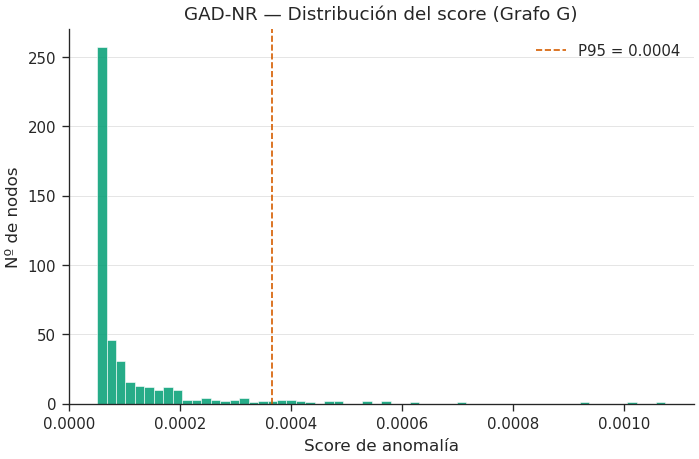

In [12]:
# Distribución del score de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(gadnr_score, bins=60, color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gadnr = np.percentile(gadnr_score, 95)
ax.axvline(p95_gadnr, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gadnr:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Distribución del score (Grafo G)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '06_gadnr_score_distribution_G.png')
plt.show()


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_score_distributions_G.png


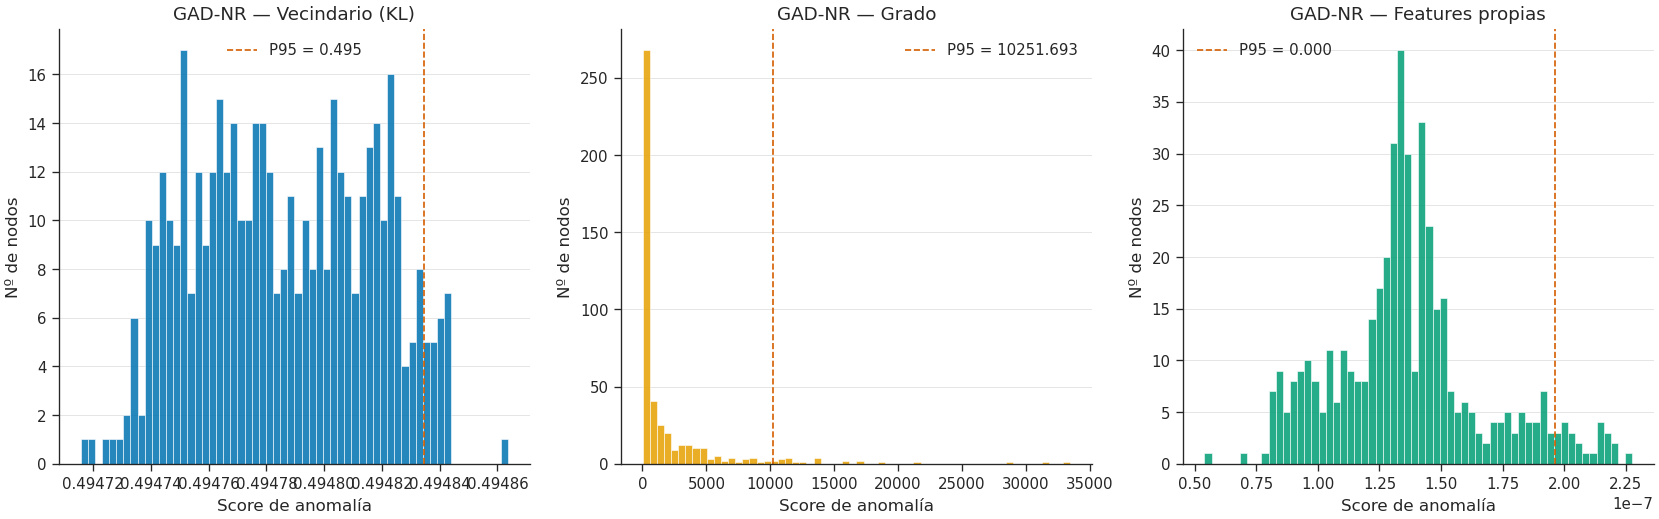

Correlación Spearman entre sub-scores de GAD-NR:
  Vecindario vs Grado   : ρ = 0.5448
  Vecindario vs Features: ρ = 0.1849
  Grado      vs Features: ρ = 0.5567


In [13]:
# Distribución de los sub-scores de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

scores_info = [
    (gadnr_h,    'Vecindario (KL)',  CAT_COLORS[0]),
    (gadnr_deg,  'Grado',            CAT_COLORS[1]),
    (gadnr_feat, 'Features propias', CAT_COLORS[2]),
]

fig, axes = plt.subplots(1, 3, figsize=FS['r1c3'])

for ax, (scores, label, color) in zip(axes, scores_info):
    ax.hist(scores, bins=60, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label}', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '06_gadnr_score_distributions_G.png')
plt.show()

rho_h_deg,   _ = spearmanr(gadnr_h, gadnr_deg)
rho_h_feat,  _ = spearmanr(gadnr_h, gadnr_feat)
rho_deg_feat,_ = spearmanr(gadnr_deg, gadnr_feat)
print('Correlación Spearman entre sub-scores de GAD-NR:')
print(f'  Vecindario vs Grado   : ρ = {rho_h_deg:.4f}')
print(f'  Vecindario vs Features: ρ = {rho_h_feat:.4f}')
print(f'  Grado      vs Features: ρ = {rho_deg_feat:.4f}')


### 4.1 Comportamiento del curriculum en el grafo G

Sección a completar tras la ejecución del modelo. El objetivo es comparar los lambdas finales
obtenidos en este grafo con los del grafo M (0.01 / 7.6 / 2.4·10⁻⁵), para confirmar o
rechazar la hipótesis de que en G — con muchas más features y menor rango de grado — el
curriculum produce un reescalado menos extremo.

Los resultados numéricos exactos se documentarán después de la ejecución.


## 5. Comparativa por tipo de señal

Misma estructura que en el notebook 05: cinco señales (dos de DOMINANT, tres de GAD-NR)
interpretadas como independientes y comparadas mediante percentiles, correlaciones Spearman
y solapamiento top-K. El umbral de anomalía es P95.

| Señal | Modelo | Tipo de anomalía |
|-------|--------|------------------|
| `dom_struct` | DOMINANT | Estructural — conectividad inusual |
| `dom_attr` | DOMINANT | Atributo — features distintas a la mayoría |
| `gadnr_deg` | GAD-NR | Estructural — grado inusual |
| `gadnr_feat` | GAD-NR | Atributo — features distintas |
| `gadnr_h` | GAD-NR | **Joint-type** — features incompatibles con el vecindario |


In [14]:
# Sub-scores al DataFrame
scores_df = base_df.copy()
scores_df['dom_struct']  = dom_struct
scores_df['dom_attr']    = dom_attr
scores_df['dom_combined'] = dominant.decision_score_.cpu().numpy()
scores_df['gadnr_h']     = gadnr_h
scores_df['gadnr_deg']   = gadnr_deg
scores_df['gadnr_feat']  = gadnr_feat
scores_df['gadnr_score'] = gadnr.decision_score_.cpu().numpy()

# Percentiles de cada señal
scores_df['pct_dom_struct']  = rankdata(dom_struct)  / len(dom_struct)  * 100
scores_df['pct_dom_attr']    = rankdata(dom_attr)    / len(dom_attr)    * 100
scores_df['pct_gadnr_deg']   = rankdata(gadnr_deg)   / len(gadnr_deg)   * 100
scores_df['pct_gadnr_feat']  = rankdata(gadnr_feat)  / len(gadnr_feat)  * 100
scores_df['pct_gadnr_h']     = rankdata(gadnr_h)     / len(gadnr_h)     * 100

P_THRESH = 95

print(f'DataFrame listo: {scores_df.shape}')
print('Columnas:', list(scores_df.columns))


DataFrame listo: (456, 19)
Columnas: ['group_id', 'idx', 'name', 'category_name', 'num_members', 'organizer_id', 'degree', 'dom_struct', 'dom_attr', 'dom_combined', 'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score', 'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']


### 5.1 Comparativa estructural: DOMINANT vs GAD-NR

Comparamos `dom_struct` (error de reconstrucción de adyacencia de DOMINANT)
con `gadnr_deg` (error de reconstrucción de grado de GAD-NR). Ambas señales
capturan anomalías estructurales pero desde perspectivas distintas: DOMINANT
mide si los enlaces del nodo se pueden reconstruir, mientras que GAD-NR mide
si su grado es predecible desde su embedding.

Los valores exactos de correlación y solapamiento se documentarán tras la ejecución.


In [15]:
rho_struct, _ = spearmanr(dom_struct, gadnr_deg)
print(f'Correlación Spearman dom_struct vs gadnr_deg: ρ = {rho_struct:.4f}')

# Solapamiento top-K — usamos K=50 porque el grafo solo tiene 456 nodos
# (top-100 sería >20% del grafo, demasiado permisivo)
K = 50
top_dom_struct   = set(np.argsort(-scores_df['dom_struct'].values)[:K])
top_gadnr_deg    = set(np.argsort(-scores_df['gadnr_deg'].values)[:K])
overlap_struct   = len(top_dom_struct & top_gadnr_deg)
print(f'Solapamiento top-{K}: {overlap_struct}/{K} nodos comunes ({overlap_struct/K:.0%})')

# Exclusivos de cada modelo en señal estructural
only_dom_struct   = top_dom_struct - top_gadnr_deg
only_gadnr_deg    = top_gadnr_deg  - top_dom_struct
print(f'Exclusivos DOMINANT-struct : {len(only_dom_struct)}')
print(f'Exclusivos GAD-NR-deg      : {len(only_gadnr_deg)}')


Correlación Spearman dom_struct vs gadnr_deg: ρ = 0.9864
Solapamiento top-50: 39/50 nodos comunes (78%)
Exclusivos DOMINANT-struct : 11
Exclusivos GAD-NR-deg      : 11


In [16]:
# Solapamiento top-50
for k in [50]:
    top_d = set(np.argsort(-scores_df['dom_struct'].values)[:k])
    top_g = set(np.argsort(-scores_df['gadnr_deg'].values)[:k])
    overlap = len(top_d & top_g)
    print(f'Solapamiento top-{k}: {overlap}/{k} ({overlap/k:.0%})')

# Solapamiento por umbral P95 (outliers detectados por ambos)
ambos_p95 = ((scores_df['pct_dom_struct'] >= P_THRESH) &
             (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_struct'] >= P_THRESH) &
              (scores_df['pct_gadnr_deg']  <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_struct'] <  P_THRESH) &
              (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'\nOutliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')

Solapamiento top-50: 39/50 (78%)

Outliers P95 detectados por ambos : 14 (44% de la unión)
Solo DOMINANT                      : 9 (28%)
Solo GAD-NR                        : 9 (28%)
Jaccard P95                        : 0.438


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_structural_comparison_G.png


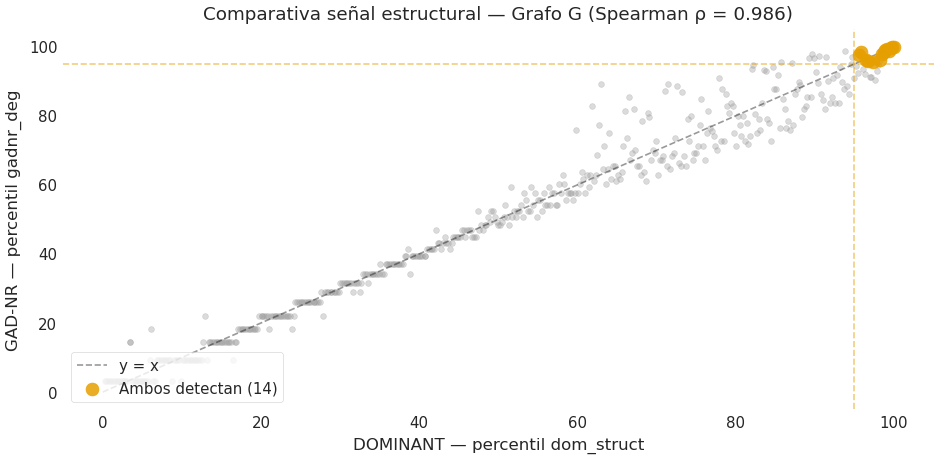

In [17]:
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_struct'], scores_df['pct_gadnr_deg'],
    s=12, alpha=0.35, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['G'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['G'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color="black",
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

ambos_struct = scores_df[
    (scores_df['pct_dom_struct'] >= P_THRESH) &
    (scores_df['pct_gadnr_deg']  >= P_THRESH)
]
ax.scatter(ambos_struct['pct_dom_struct'], ambos_struct['pct_gadnr_deg'],
           s=60, alpha=0.85, color=PALETTE['G'], zorder=3,
           label=f'Ambos detectan ({len(ambos_struct)})')

ax.set_xlabel('DOMINANT — percentil dom_struct', fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_deg',   fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal estructural — Grafo G (Spearman ρ = {rho_struct:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True, loc='lower left')
ax.tick_params(labelsize=FONT['tick'], length=0)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '06_structural_comparison_G.png')
plt.show()


### 5.2 Comparativa de atributos: DOMINANT vs GAD-NR

Comparamos `dom_attr` con `gadnr_feat`. Ambas miden anomalía de atributo pero con
mecanismos distintos — DOMINANT usa un decoder GCN que reconstruye X desde Z mediante
la estructura del grafo, mientras que GAD-NR usa un MLP puro sin estructura.

En el grafo G, donde las features son ricas (35 dimensiones: tamaño, actividad, categoría),
se espera que esta comparación sea más informativa que en el grafo M (3 features geográficas).


In [18]:
rho_attr, _ = spearmanr(dom_attr, gadnr_feat)
print(f'Correlación Spearman dom_attr vs gadnr_feat: ρ = {rho_attr:.4f}')

# Solapamiento top-50
top_dom_attr    = set(np.argsort(-scores_df['dom_attr'].values)[:K])
top_gadnr_feat  = set(np.argsort(-scores_df['gadnr_feat'].values)[:K])
overlap_attr    = len(top_dom_attr & top_gadnr_feat)
print(f'Solapamiento top-{K}: {overlap_attr}/{K} nodos comunes ({overlap_attr/K:.0%})')

only_dom_attr   = top_dom_attr  - top_gadnr_feat
only_gadnr_feat = top_gadnr_feat - top_dom_attr
print(f'Exclusivos DOMINANT-attr : {len(only_dom_attr)}')
print(f'Exclusivos GAD-NR-feat   : {len(only_gadnr_feat)}')


Correlación Spearman dom_attr vs gadnr_feat: ρ = -0.4663
Solapamiento top-50: 0/50 nodos comunes (0%)
Exclusivos DOMINANT-attr : 50
Exclusivos GAD-NR-feat   : 50


In [19]:
# Solapamiento top-50 
for k in [50]:
    top_d = set(np.argsort(-scores_df['dom_attr'].values)[:k])
    top_g = set(np.argsort(-scores_df['gadnr_feat'].values)[:k])
    overlap = len(top_d & top_g)
    print(f'Solapamiento top-{k}: {overlap}/{k} ({overlap/k:.0%})')

# Solapamiento por umbral P95
ambos_p95 = ((scores_df['pct_dom_attr']   >= P_THRESH) &
             (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_attr']   >= P_THRESH) &
              (scores_df['pct_gadnr_feat'] <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_attr']   <  P_THRESH) &
              (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'\nOutliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')

Solapamiento top-50: 0/50 (0%)

Outliers P95 detectados por ambos : 0 (0% de la unión)
Solo DOMINANT                      : 23 (50%)
Solo GAD-NR                        : 23 (50%)
Jaccard P95                        : 0.000


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_attribute_comparison_G.png


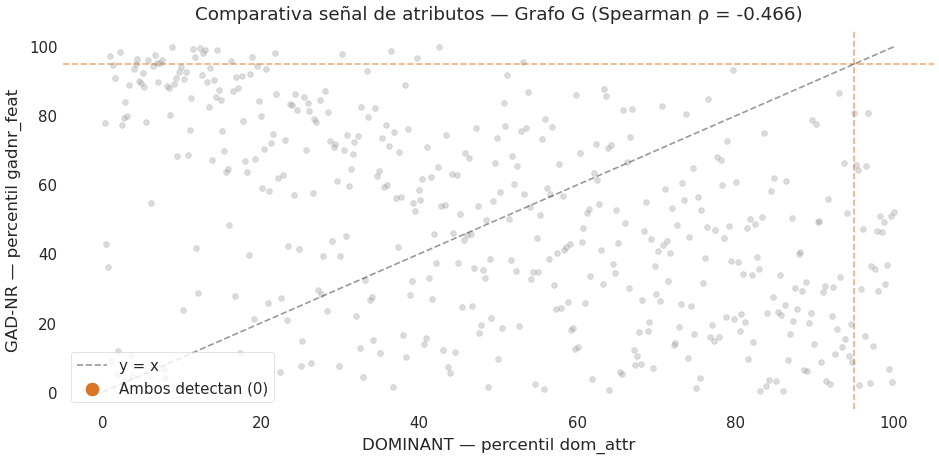

In [20]:
# Scatter comparativa de atributos: dom_attr (X) vs gadnr_feat (Y)
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_attr'], scores_df['pct_gadnr_feat'],
    s=12, alpha=0.35, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color="black",
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

ambos_attr = scores_df[
    (scores_df['pct_dom_attr']   >= P_THRESH) &
    (scores_df['pct_gadnr_feat'] >= P_THRESH)
]
ax.scatter(ambos_attr['pct_dom_attr'], ambos_attr['pct_gadnr_feat'],
           s=60, alpha=0.85, color=PALETTE['anomaly'], zorder=3,
           label=f'Ambos detectan ({len(ambos_attr)})')

ax.set_xlabel('DOMINANT — percentil dom_attr',  fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_feat', fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal de atributos — Grafo G (Spearman ρ = {rho_attr:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True, loc='lower left')
ax.tick_params(labelsize=FONT['tick'], length=0)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '06_attribute_comparison_G.png')
plt.show()


### 5.3 Scatter de tipología por modelo

Para cada modelo construimos el scatter estructural vs atributo con la tipología de
anomalías resultante. La asignación de tipo se hace por superación del P95 en cada eje:
**Estructural** si solo supera el estructural, **Atributo** si solo el de atributo,
**Mixta** si supera ambos y **Normal** en caso contrario.


In [21]:
# Tipología DOMINANT: dom_struct vs dom_attr
def assign_type_dom(row):
    hs = row['pct_dom_struct'] >= P_THRESH
    ha = row['pct_dom_attr']   >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

# Tipología GAD-NR: gadnr_deg vs gadnr_feat
def assign_type_gadnr(row):
    hs = row['pct_gadnr_deg']  >= P_THRESH
    ha = row['pct_gadnr_feat'] >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

scores_df['type_dom']   = scores_df.apply(assign_type_dom,   axis=1)
scores_df['type_gadnr'] = scores_df.apply(assign_type_gadnr, axis=1)

print('=== Tipología DOMINANT (dom_struct vs dom_attr) ===')
for t, c in scores_df['type_dom'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')

print('=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===')
for t, c in scores_df['type_gadnr'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')


=== Tipología DOMINANT (dom_struct vs dom_attr) ===
  Normal         :   410 (89.9%)
  Estructural    :    23 (5.0%)
  Atributo       :    23 (5.0%)
=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===
  Normal         :   410 (89.9%)
  Estructural    :    23 (5.0%)
  Atributo       :    23 (5.0%)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_typology_dominant_G.png


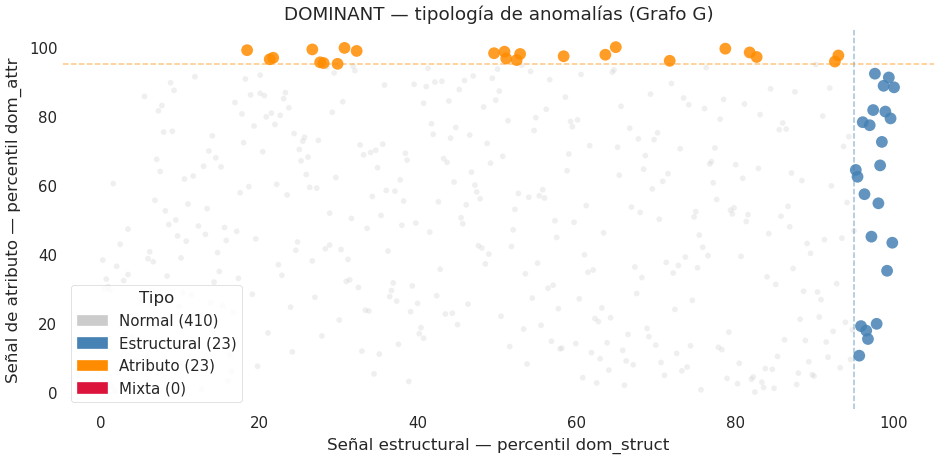

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_typology_gadnr_G.png


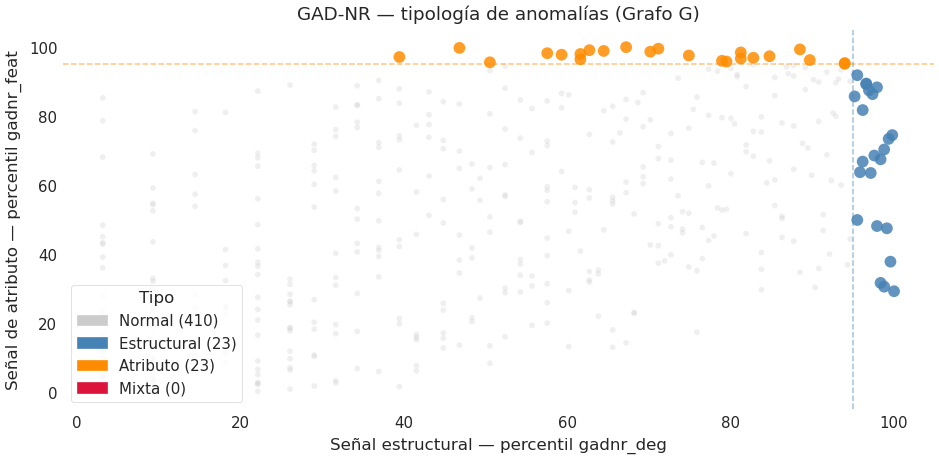

In [22]:
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {'Normal': '#cccccc', 'Estructural': 'steelblue', 'Atributo': 'darkorange', 'Mixta': 'crimson'}

def plot_typology_scatter(ax, type_col, xcol, ycol, score_col, title,
                          xlabel, ylabel):
    """Scatter de tipología para un modelo: x=estructural, y=atributo,
    coloreado por tipo asignado."""

    for atype in TIPO_ORDER:
        group  = scores_df[scores_df[type_col] == atype]
        size   = 50 if atype != 'Normal' else 12
        alpha  = 0.85 if atype != 'Normal' else 0.30
        zorder = 3 if atype != 'Normal' else 1
        ax.scatter(group[xcol], group[ycol],
                   s=size, alpha=alpha, color=color_map[atype],
                   label=f'{atype} ({len(group)})', zorder=zorder,
                   edgecolors='none')

    ax.axvline(P_THRESH, color=color_map['Estructural'], linestyle='--',
               linewidth=0.9, alpha=0.5)
    ax.axhline(P_THRESH, color=color_map['Atributo'],    linestyle='--',
               linewidth=0.9, alpha=0.5)

    legend_patches = [mpatches.Patch(color=color_map[t],
                                     label=f"{t} ({(scores_df[type_col]==t).sum()})")
                      for t in TIPO_ORDER]
    ax.legend(handles=legend_patches, title='Tipo',
              title_fontsize=FONT['legend'] + 1,
              fontsize=FONT['legend'],
              frameon=True, facecolor='white', framealpha=0.85,
              edgecolor='#CCCCCC', loc='lower left')

    ax.set_xlabel(xlabel, fontsize=FONT['axis_label'])
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_title(title, fontsize=FONT['title'])
    ax.tick_params(labelsize=FONT['tick'], length=0)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── Figura 1: DOMINANT ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(
    ax,
    type_col='type_dom',
    xcol='pct_dom_struct', ycol='pct_dom_attr',
    score_col='dom_combined',
    title='DOMINANT — tipología de anomalías (Grafo G)',
    xlabel='Señal estructural — percentil dom_struct',
    ylabel='Señal de atributo — percentil dom_attr',
)
plt.tight_layout()
save_figure(fig, '06_typology_dominant_G.png')
plt.show()


# ── Figura 2: GAD-NR ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(
    ax,
    type_col='type_gadnr',
    xcol='pct_gadnr_deg', ycol='pct_gadnr_feat',
    score_col='gadnr_score',
    title='GAD-NR — tipología de anomalías (Grafo G)',
    xlabel='Señal estructural — percentil gadnr_deg',
    ylabel='Señal de atributo — percentil gadnr_feat',
)
plt.tight_layout()
save_figure(fig, '06_typology_gadnr_G.png')
plt.show()


### 5.4 Distribución del score compuesto por arquitectura

Cada arquitectura agrega sus sub-scores en un único score compuesto. La comparación directa
de los valores brutos es poco informativa porque las escalas dependen del modelo y del
curriculum interno de GAD-NR. La comparación útil es a nivel de ranking.


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_composite_score_distributions_G.png


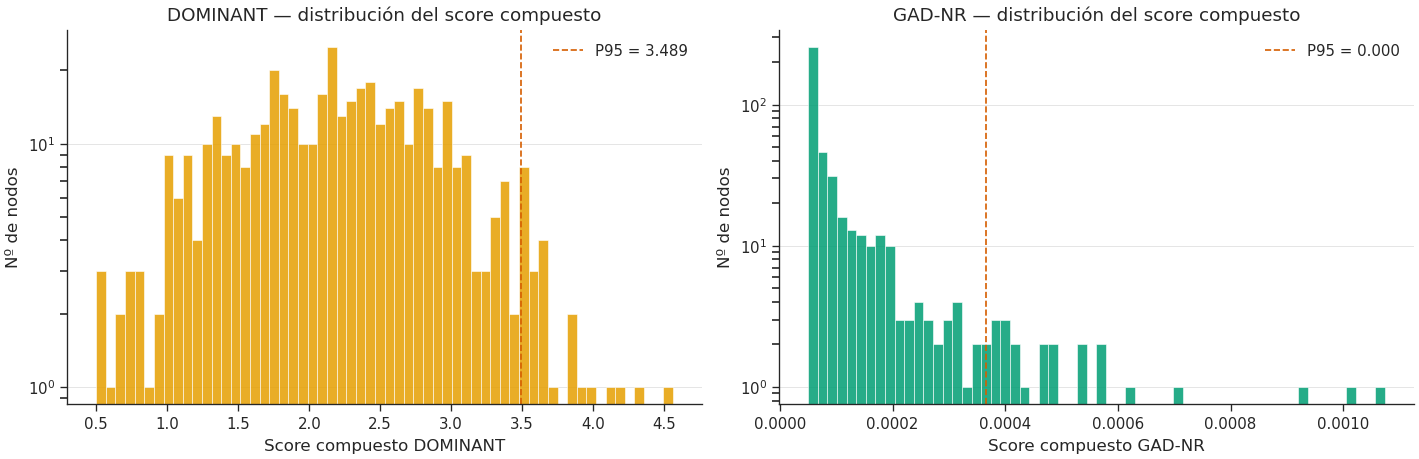

=== Score compuesto — DOMINANT ===
count    456.000000
mean       2.213046
std        0.734737
min        0.499462
25%        1.701101
50%        2.196677
75%        2.737669
max        4.561234

=== Score compuesto — GAD-NR ===
count    456.000000
mean       0.000111
std        0.000124
min        0.000050
25%        0.000053
50%        0.000062
75%        0.000108
max        0.001074

Correlación Spearman dom_combined vs gadnr_score: ρ = 0.8896
Solapamiento top-50: 29/50 (58%)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

# DOMINANT
ax = axes[0]
ax.hist(scores_df['dom_combined'], bins=60,
        color=PALETTE['G'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(scores_df['dom_combined'], 95)
ax.axvline(p95_dom, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.3f}')
ax.set_xlabel('Score compuesto DOMINANT', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — distribución del score compuesto',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
polish(ax)

# GAD-NR
ax = axes[1]
ax.hist(scores_df['gadnr_score'], bins=60,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gad = np.percentile(scores_df['gadnr_score'], 95)
ax.axvline(p95_gad, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gad:.3f}')
ax.set_xlabel('Score compuesto GAD-NR', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — distribución del score compuesto',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
polish(ax)

plt.tight_layout()
save_figure(fig, '06_composite_score_distributions_G.png')
plt.show()

# Estadísticos descriptivos del score compuesto
print('=== Score compuesto — DOMINANT ===')
print(scores_df['dom_combined'].describe().to_string())
print('\n=== Score compuesto — GAD-NR ===')
print(scores_df['gadnr_score'].describe().to_string())

# Correlación Spearman entre los dos scores compuestos
rho_comp, _ = spearmanr(scores_df['dom_combined'], scores_df['gadnr_score'])
print(f'\nCorrelación Spearman dom_combined vs gadnr_score: ρ = {rho_comp:.4f}')

# Solapamiento del top-K
top_dom = set(np.argsort(-scores_df['dom_combined'].values)[:K])
top_gad = set(np.argsort(-scores_df['gadnr_score'].values)[:K])
print(f'Solapamiento top-{K}: {len(top_dom & top_gad)}/{K} '
      f'({len(top_dom & top_gad)/K:.0%})')


### 5.5 Señal joint-type de GAD-NR (análisis independiente)

La señal **`gadnr_h`** (divergencia KL entre la distribución real de atributos del vecindario
y la reconstruida) es la única capaz de detectar anomalías **joint-type**: grupos cuyas
features son normales en sí mismas pero no encajan con las de sus vecinos.

En el grafo G esta señal puede ser especialmente interesante porque los grupos tienen
features ricas y específicas (categoría temática, tamaño, actividad). Un grupo cuya categoría
o tamaño sea inusual respecto a los grupos con los que comparte miembros sería un candidato
joint-type natural.


In [24]:
# Nodos joint-type puros — alto gadnr_h sin anomalía estructural ni de atributo en DOMINANT
pure_joint = scores_df[
    (scores_df['pct_gadnr_h']    >= P_THRESH) &
    (scores_df['pct_dom_struct'] <  P_THRESH) &
    (scores_df['pct_dom_attr']   <  P_THRESH)
].copy()

print(f'Grupos joint-type puros (invisibles para DOMINANT): {len(pure_joint)}')
print(f'  Grado medio: {pure_joint["degree"].mean():.1f} '
      f'(vs {scores_df["degree"].mean():.1f} global)')
print()
print('Top-10 por gadnr_h:')
print(
    pure_joint.nlargest(10, 'gadnr_h')[
        ['name', 'category_name', 'num_members', 'degree',
         'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_h']
    ].to_string(index=False)
)


Grupos joint-type puros (invisibles para DOMINANT): 6
  Grado medio: 20.3 (vs 14.4 global)

Top-10 por gadnr_h:
                                               name           category_name  num_members  degree  pct_dom_struct  pct_dom_attr  pct_gadnr_h
                   PROVIDENT LIVING & SELF-RELIANCE    Education & Learning          777      22       83.114035     80.482456   100.000000
                    Nashville Entrepreneurs Network       Career & Business         1192      13       61.622807     71.491228    98.903509
                                Volunteer Nashville Community & Environment         2921      19       78.070175     79.166667    98.574561
                            Nashville Kayak Lessons    Outdoors & Adventure         3260      16       69.298246     86.403509    96.600877
                        Nashville Backpacker Meetup    Outdoors & Adventure         3861      30       91.008772     80.043860    96.052632
Middle Tennessee Sierra Club Outings and Adventu

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_joint_type_G.png


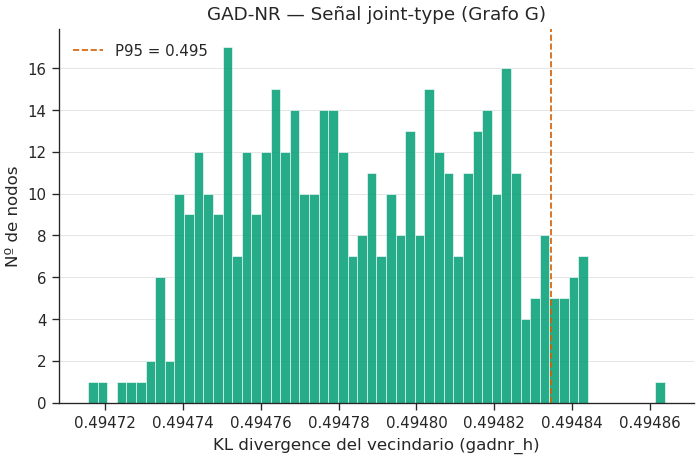

In [25]:
# Distribución del score joint-type
fig, ax = plt.subplots(figsize=FS['single'])

ax.hist(scores_df['gadnr_h'], bins=60,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_h = np.percentile(scores_df['gadnr_h'], 95)
ax.axvline(p95_h, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_h:.3f}')

ax.set_xlabel('KL divergence del vecindario (gadnr_h)', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Señal joint-type (Grafo G)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '06_gadnr_joint_type_G.png')
plt.show()


## 6. Spotlight — candidatos del EDA

Revisamos los candidatos a anomalía identificados en el EDA del grafo G con las cinco señales
de los modelos. Los candidatos principales del EDA fueron:

- **Stepping Out Social Dance Meetup** — mayor grado de la red (182), grupo más conectado.
- **Nashville Hiking Meetup** — grupo más grande (15.838 miembros) pero grado moderado (136).
- **NashJS** — hub tecnológico extremo, aparece en 6 de las 10 aristas más pesadas.
- **Nashville Children in Nature** — grupo grande (654 miembros) pero clustering 0.
- **Sunday Assembly Nashville** — Religion & Beliefs en top-10 de betweenness.
- **Lesbians in the Workplace** — ratio inter-comunidad más alto (0.842).
- **Christianity & Transhumanism** — miembro de la microcomunidad C3 (4 nodos).


In [26]:
def spotlight(name_fragment, df, label=None):
    matches = df[df['name'].str.contains(name_fragment, case=False, na=False)]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}')
        return
    row = matches.iloc[0]
    n   = len(df)
    def rank(col): return int((df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ' '

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Categoría: {row["category_name"]} | Miembros: {row["num_members"]} | Grado: {row["degree"]}')
    print(f'    DOMINANT  estructural : #{rank("dom_struct"):4d}/{n}  '
          f'({row["pct_dom_struct"]:.1f}p) {flag(row["pct_dom_struct"])}')
    print(f'    DOMINANT  atributo    : #{rank("dom_attr"):4d}/{n}  '
          f'({row["pct_dom_attr"]:.1f}p) {flag(row["pct_dom_attr"])}')
    print(f'    GAD-NR    estructural : #{rank("gadnr_deg"):4d}/{n}  '
          f'({row["pct_gadnr_deg"]:.1f}p) {flag(row["pct_gadnr_deg"])}')
    print(f'    GAD-NR    atributo    : #{rank("gadnr_feat"):4d}/{n}  '
          f'({row["pct_gadnr_feat"]:.1f}p) {flag(row["pct_gadnr_feat"])}')
    print(f'    GAD-NR    joint-type  : #{rank("gadnr_h"):4d}/{n}  '
          f'({row["pct_gadnr_h"]:.1f}p) {flag(row["pct_gadnr_h"])}')
    print()

print('=' * 70)
print('CANDIDATOS DEL EDA — LAS 5 SEÑALES')
print('=' * 70 + '\n')

candidatos = [
    ('Stepping Out',     'Stepping Out Social Dance Meetup (grado máximo)'),
    ('Nashville Hiking', 'Nashville Hiking Meetup (grupo más grande)'),
    ('NashJS',           'NashJS (hub tecnológico extremo)'),
    ('Children in Nature','Nashville Children in Nature (clustering 0)'),
    ('Sunday Assembly',  'Sunday Assembly Nashville (Religion en top betweenness)'),
    ('Lesbians in the Workplace', 'Lesbians in the Workplace (ratio inter-comunidad alto)'),
    ('Christianity',     'Christianity & Transhumanism (microcomunidad C3)'),
]

for frag, label in candidatos:
    spotlight(frag, scores_df, label=label)


CANDIDATOS DEL EDA — LAS 5 SEÑALES

  ► Stepping Out Social Dance Meetup (grado máximo)
    Categoría: Dancing | Miembros: 1778 | Grado: 91
    DOMINANT  estructural : #   1/456  (100.0p) ⚠
    DOMINANT  atributo    : #  54/456  (88.4p)  
    GAD-NR    estructural : #   1/456  (100.0p) ⚠
    GAD-NR    atributo    : # 323/456  (29.4p)  
    GAD-NR    joint-type  : #  23/456  (95.1p) ⚠

  ► Nashville Hiking Meetup (grupo más grande)
    Categoría: Outdoors & Adventure | Miembros: 15838 | Grado: 68
    DOMINANT  estructural : #   6/456  (98.9p) ⚠
    DOMINANT  atributo    : #  86/456  (81.4p)  
    GAD-NR    estructural : #   5/456  (99.1p) ⚠
    GAD-NR    atributo    : # 240/456  (47.6p)  
    GAD-NR    joint-type  : #   4/456  (99.2p) ⚠

  ► NashJS (hub tecnológico extremo)
    Categoría: Tech | Miembros: 1975 | Grado: 53
    DOMINANT  estructural : #  50/456  (89.3p)  
    DOMINANT  atributo    : # 416/456  (9.0p)  
    GAD-NR    estructural : #  16/456  (96.6p) ⚠
    GAD-NR    atribut

In [27]:
# Tabla resumen ejecutivo
rows = []
for frag, label in candidatos:
    matches = scores_df[scores_df['name'].str.contains(frag, case=False, na=False)]
    if len(matches) == 0:
        continue
    row = matches.iloc[0]
    n   = len(scores_df)
    def rank(col): return int((scores_df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ''

    rows.append({
        'Candidato':      label.split('(')[0].strip(),
        'DOM-struct':     f'#{rank("dom_struct")} ({row["pct_dom_struct"]:.0f}p){flag(row["pct_dom_struct"])}',
        'DOM-attr':       f'#{rank("dom_attr")} ({row["pct_dom_attr"]:.0f}p){flag(row["pct_dom_attr"])}',
        'GADNR-struct':   f'#{rank("gadnr_deg")} ({row["pct_gadnr_deg"]:.0f}p){flag(row["pct_gadnr_deg"])}',
        'GADNR-attr':     f'#{rank("gadnr_feat")} ({row["pct_gadnr_feat"]:.0f}p){flag(row["pct_gadnr_feat"])}',
        'GADNR-joint':    f'#{rank("gadnr_h")} ({row["pct_gadnr_h"]:.0f}p){flag(row["pct_gadnr_h"])}',
    })

print('=== Resumen ejecutivo — candidatos del EDA ===')
print(pd.DataFrame(rows).to_string(index=False))


=== Resumen ejecutivo — candidatos del EDA ===
                       Candidato DOM-struct   DOM-attr GADNR-struct GADNR-attr GADNR-joint
Stepping Out Social Dance Meetup #1 (100p)⚠  #54 (88p)   #1 (100p)⚠ #323 (29p)  #23 (95p)⚠
         Nashville Hiking Meetup  #6 (99p)⚠  #86 (81p)    #5 (99p)⚠ #240 (48p)   #4 (99p)⚠
                          NashJS  #50 (89p)  #416 (9p)   #16 (97p)⚠  #50 (89p)  #172 (62p)
    Nashville Children in Nature  #453 (1p) #317 (31p)    #429 (3p) #251 (45p)   #66 (86p)
       Sunday Assembly Nashville  #7 (99p)⚠  #52 (89p)    #8 (98p)⚠ #312 (32p)   #31 (93p)
       Lesbians in the Workplace  #85 (82p) #222 (52p)   #129 (72p) #283 (38p)   #88 (81p)
    Christianity & Transhumanism #398 (13p) #158 (66p)   #346 (22p)  #433 (5p)  #408 (11p)


## 7. Comparativa general

Heatmap de correlación Spearman entre las cinco señales y análisis del acuerdo entre modelos
a nivel de etiqueta binaria (P95).


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_signal_correlation_G.png


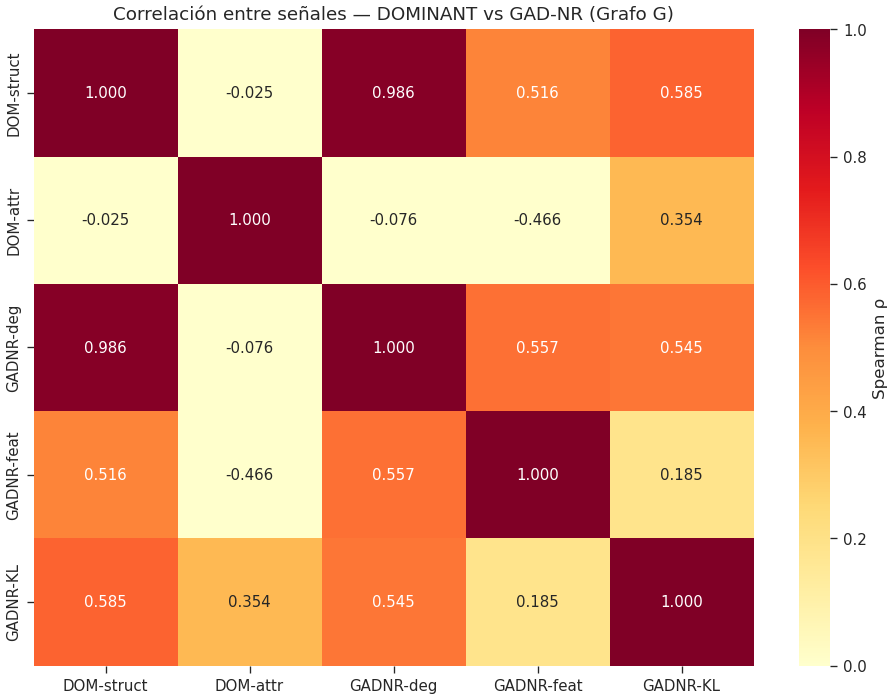

In [28]:
# Heatmap de correlación entre las 5 señales
score_cols   = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']
score_labels = ['DOM-struct', 'DOM-attr', 'GADNR-deg', 'GADNR-feat', 'GADNR-KL']

n_s = len(score_cols)
corr_matrix = np.zeros((n_s, n_s))
for i, c1 in enumerate(score_cols):
    for j, c2 in enumerate(score_cols):
        rho, _ = spearmanr(scores_df[c1], scores_df[c2])
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=FS['heatmap'])
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap=CMAP_HEAT,
    vmin=0, vmax=1, ax=ax,
    xticklabels=score_labels, yticklabels=score_labels,
    cbar_kws={'label': 'Spearman ρ'}
)
ax.set_title('Correlación entre señales — DOMINANT vs GAD-NR (Grafo G)',
             fontsize=FONT['title'])
plt.tight_layout()
save_figure(fig, '06_signal_correlation_G.png')
plt.show()


In [29]:
# Acuerdo entre tipologías: ¿asignan el mismo tipo los dos modelos?
print('=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===')
print(pd.crosstab(
    scores_df['type_dom'],
    scores_df['type_gadnr'],
    rownames=['DOMINANT'],
    colnames=['GAD-NR']
))


=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===
GAD-NR       Atributo  Estructural  Normal
DOMINANT                                  
Atributo            0            0      23
Estructural         0           14       9
Normal             23            9     378


## 8. Visualización t-SNE de los embeddings

Proyectamos los embeddings latentes de cada modelo a 2D mediante t-SNE para inspeccionar
la estructura aprendida. Tres vistas por modelo: coloreado por tipo, por score compuesto
y por grado del nodo.

**Coste computacional.** Con 456 puntos t-SNE es prácticamente instantáneo (<5 s por modelo).
Inicializamos con PCA (`init='pca'`) y fijamos `random_state=SEED` para reproducibilidad.
La perplexity por defecto (30) funciona bien para este tamaño.


In [30]:
# Extracción de embeddings finales de ambos modelos
@torch.no_grad()
def get_dominant_embeddings(detector, data):
    """
    El encoder GCN compartido de DOMINANT es la primera mitad del modelo.
    Llamamos a model.shared_encoder(x, edge_index) para obtener Z.
    """
    model = detector.model
    model.eval()
    x          = data.x.to(detector.device)
    edge_index = data.edge_index.to(detector.device)
    z = model.shared_encoder(x, edge_index)
    return z.cpu().numpy()


@torch.no_grad()
def get_gadnr_embeddings(detector, data):
    """
    GAD-NR: el encoder produce h0 (representación pre-decoder). Es el
    output de la GCN antes del MLP de reducción de vecindario.
    """
    model = detector.model
    model.eval()
    data.x          = data.x.to(detector.device)
    data.edge_index = data.edge_index.to(detector.device)
    h0, _, _, _ = model(data.x, data.edge_index)
    return h0.cpu().numpy()


emb_dom   = get_dominant_embeddings(dominant, data_G_clean)
emb_gadnr = get_gadnr_embeddings(gadnr,      data_G_clean)

print(f'Embeddings DOMINANT : {emb_dom.shape}')
print(f'Embeddings GAD-NR   : {emb_gadnr.shape}')


Embeddings DOMINANT : (456, 64)
Embeddings GAD-NR   : (456, 64)


In [31]:
from sklearn.manifold import TSNE

def run_tsne(embeddings, label):
    print(f'Calculando t-SNE sobre embeddings de {label}...')
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,
        init='pca',
        learning_rate='auto',
        random_state=SEED,
        verbose=0,
    )
    return tsne.fit_transform(embeddings)


tsne_dom   = run_tsne(emb_dom,   'DOMINANT')
tsne_gadnr = run_tsne(emb_gadnr, 'GAD-NR')

print(f't-SNE DOMINANT shape: {tsne_dom.shape}')
print(f't-SNE GAD-NR  shape: {tsne_gadnr.shape}')


Calculando t-SNE sobre embeddings de DOMINANT...
Calculando t-SNE sobre embeddings de GAD-NR...
t-SNE DOMINANT shape: (456, 2)
t-SNE GAD-NR  shape: (456, 2)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_tsne_type_G.png


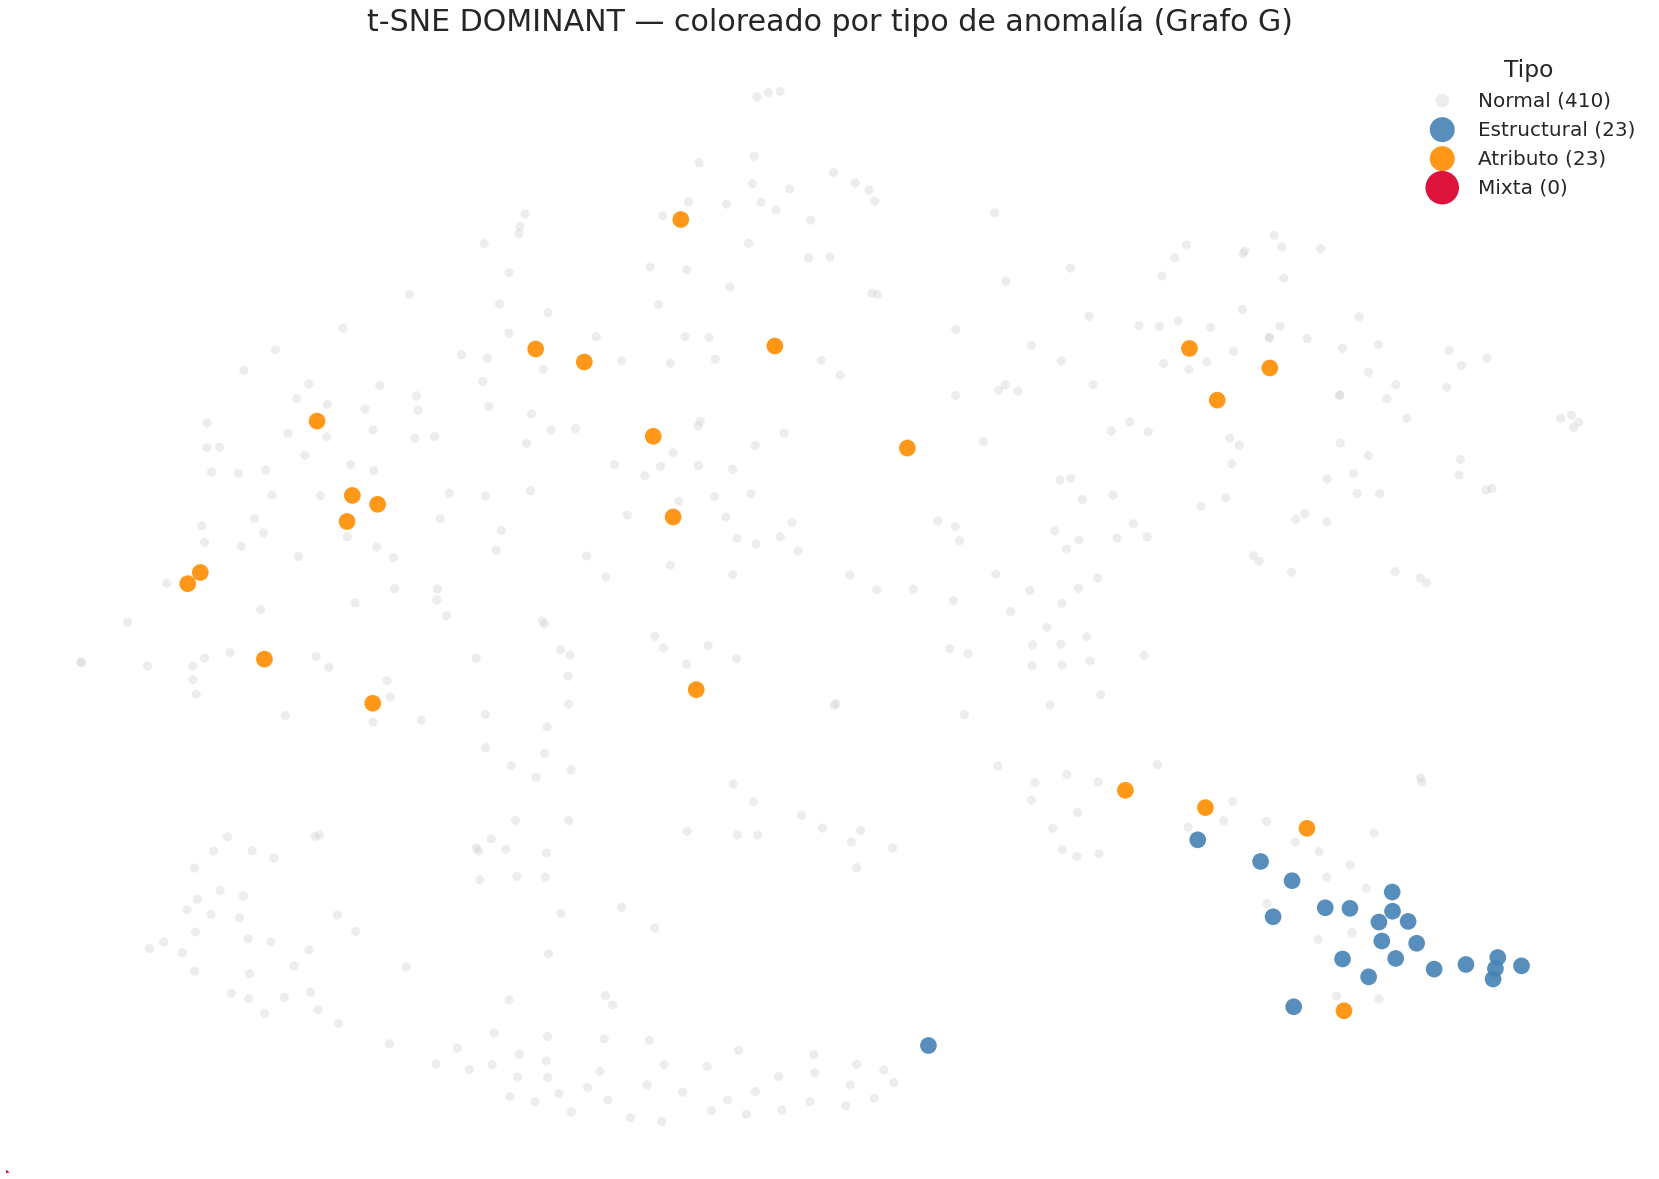

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_tsne_score_G.png


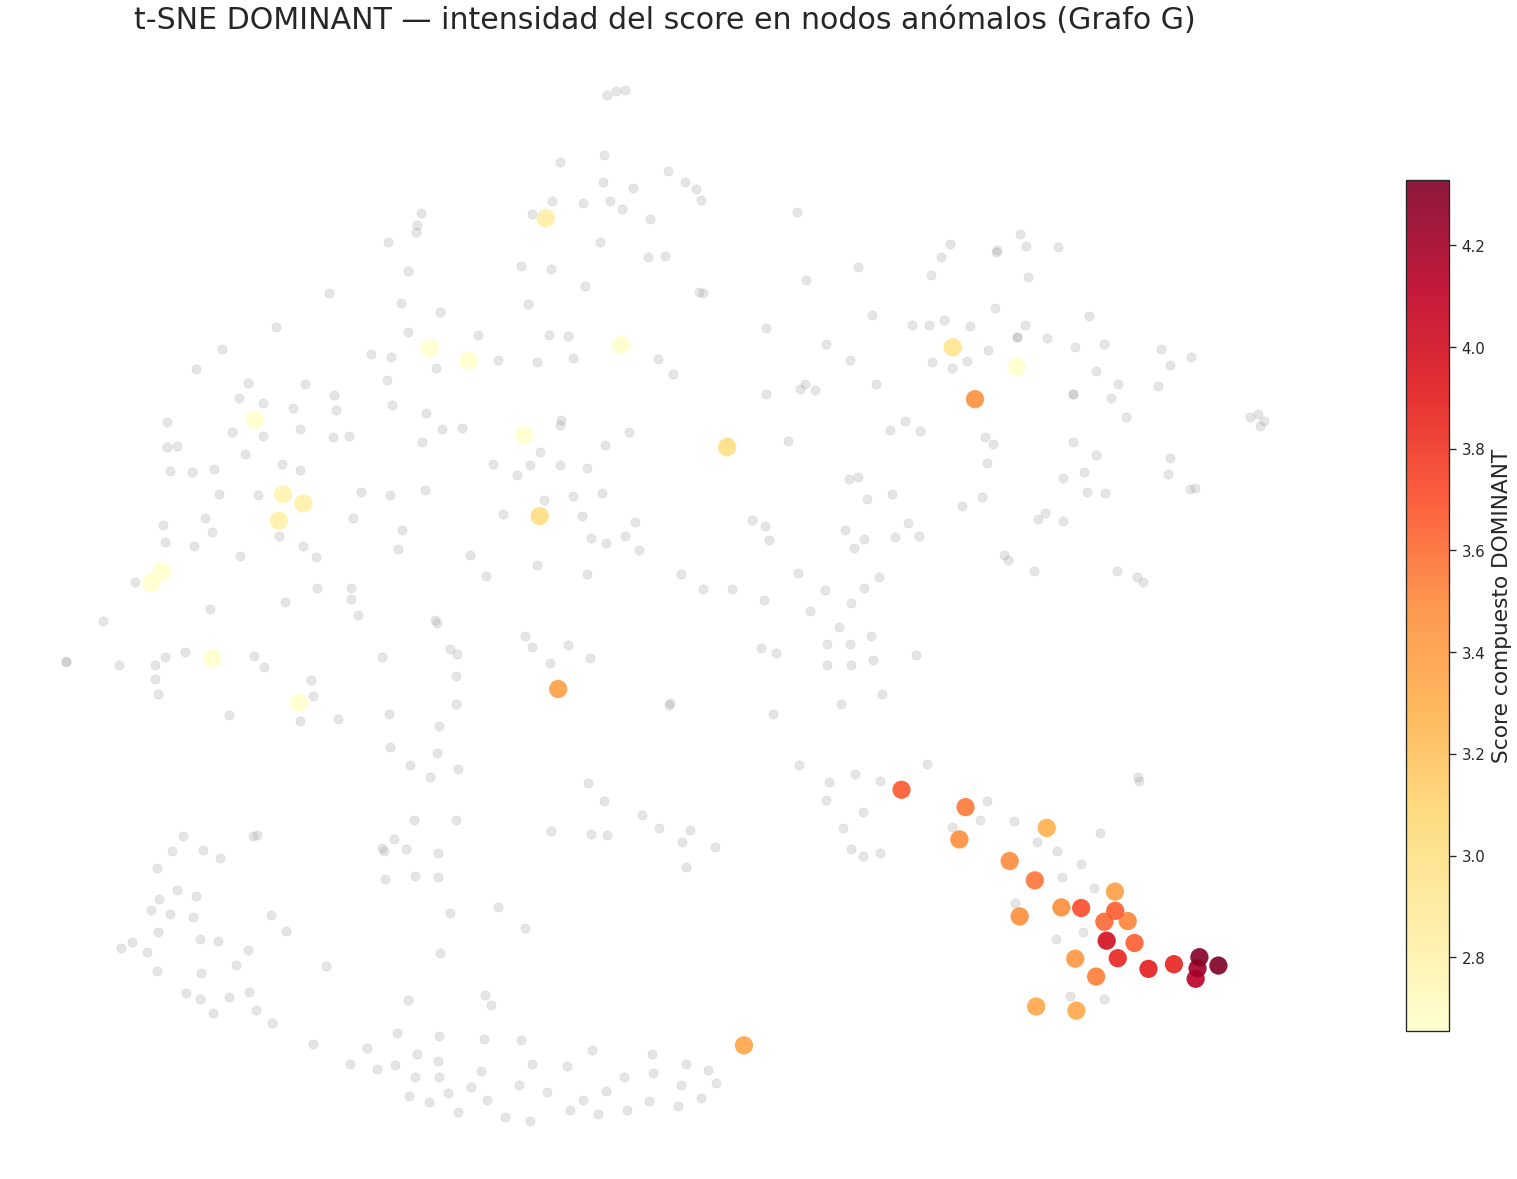

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_tsne_degree_G.png


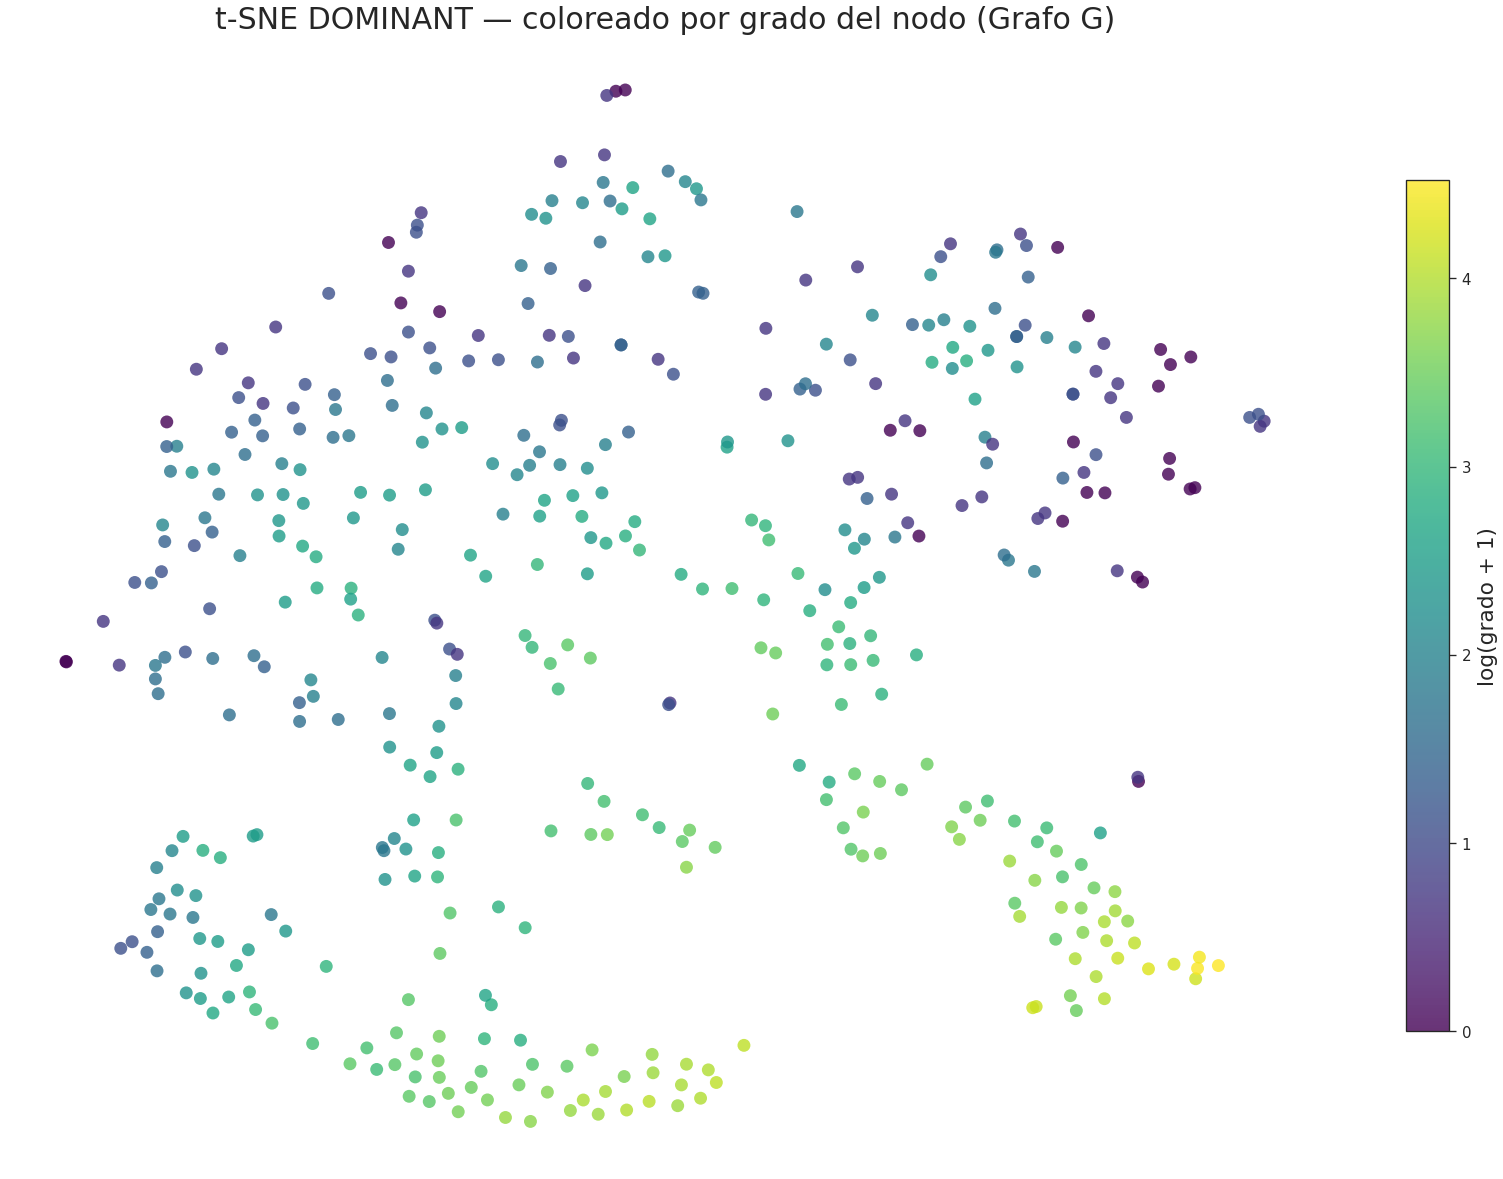

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_tsne_type_G.png


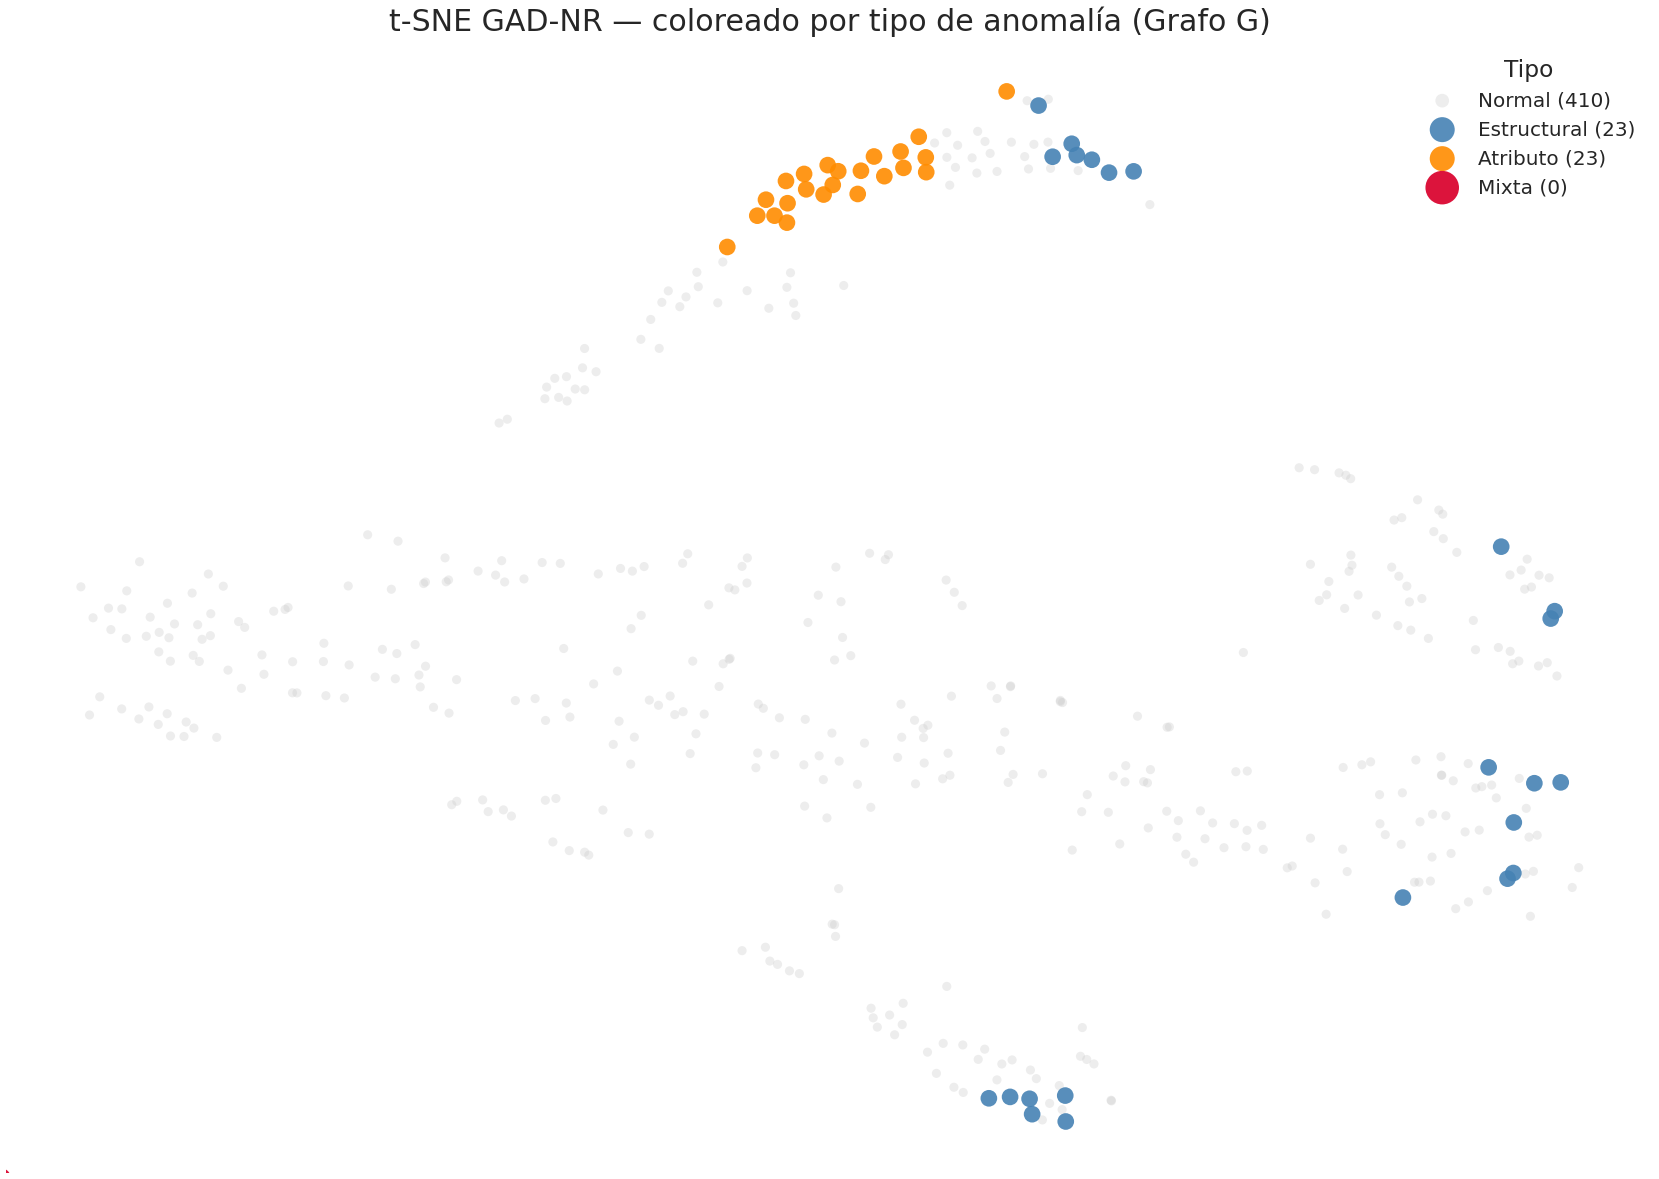

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_tsne_score_G.png


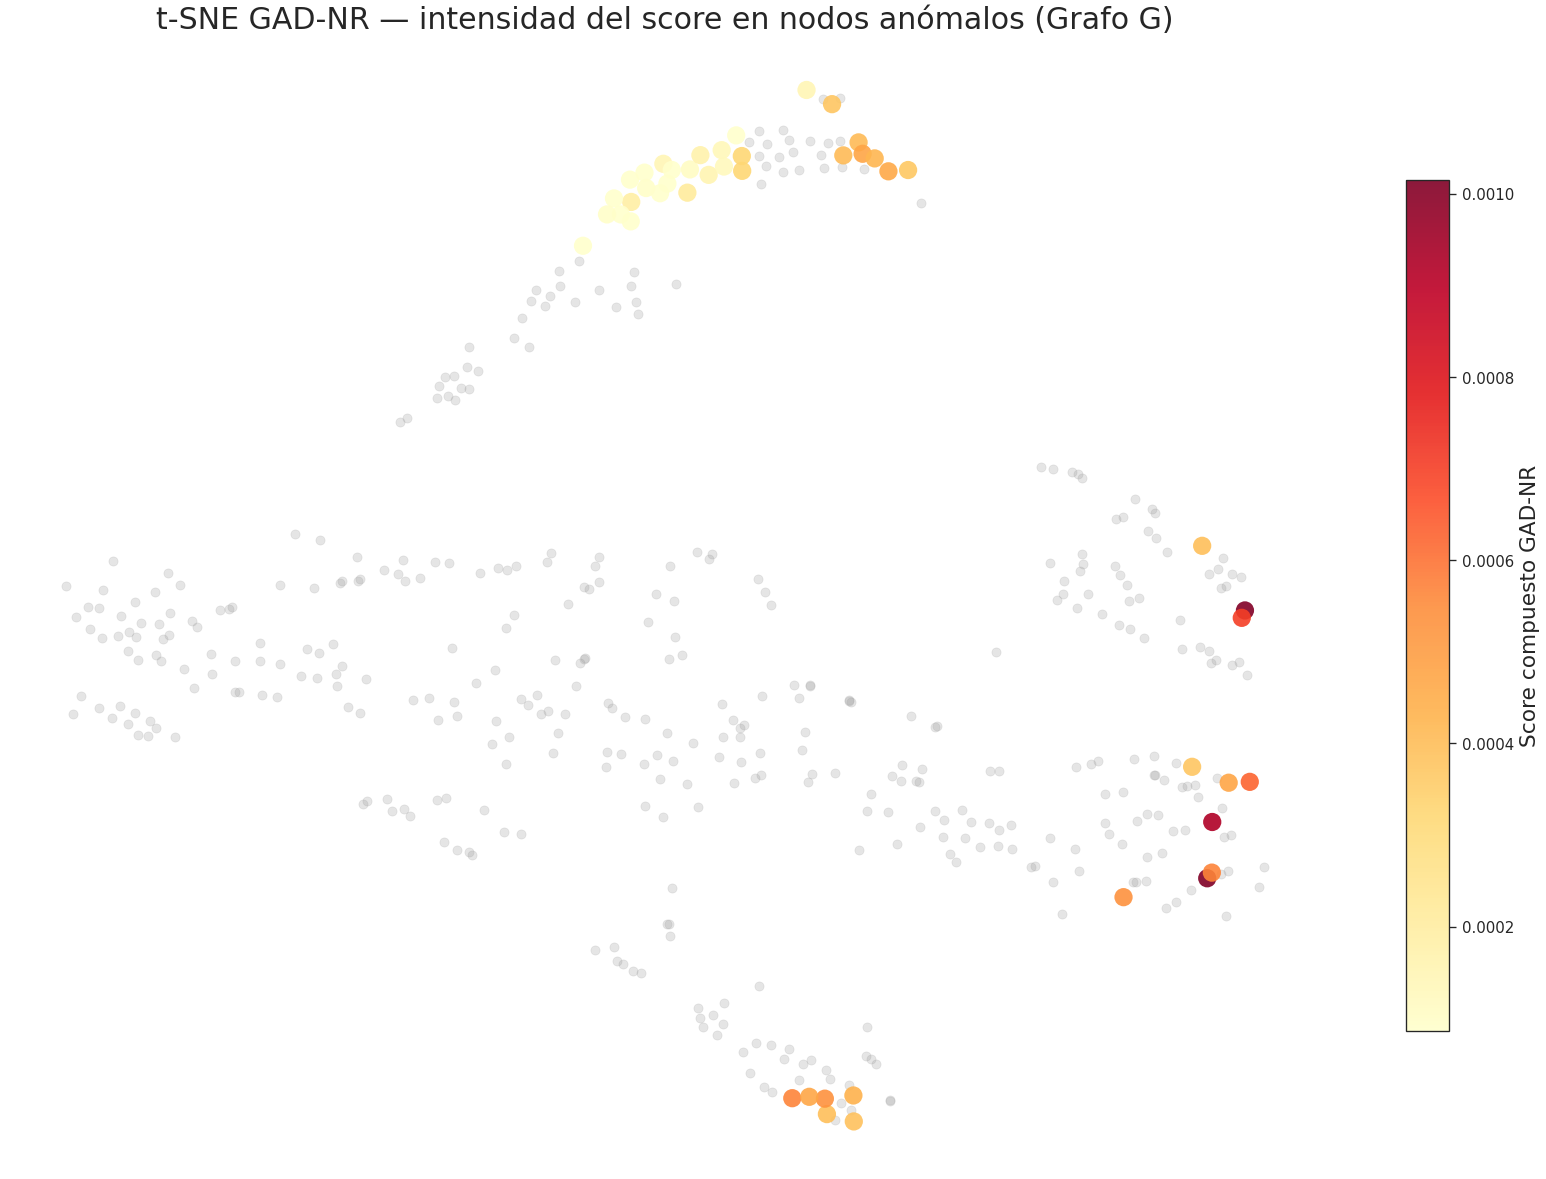

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_tsne_degree_G.png


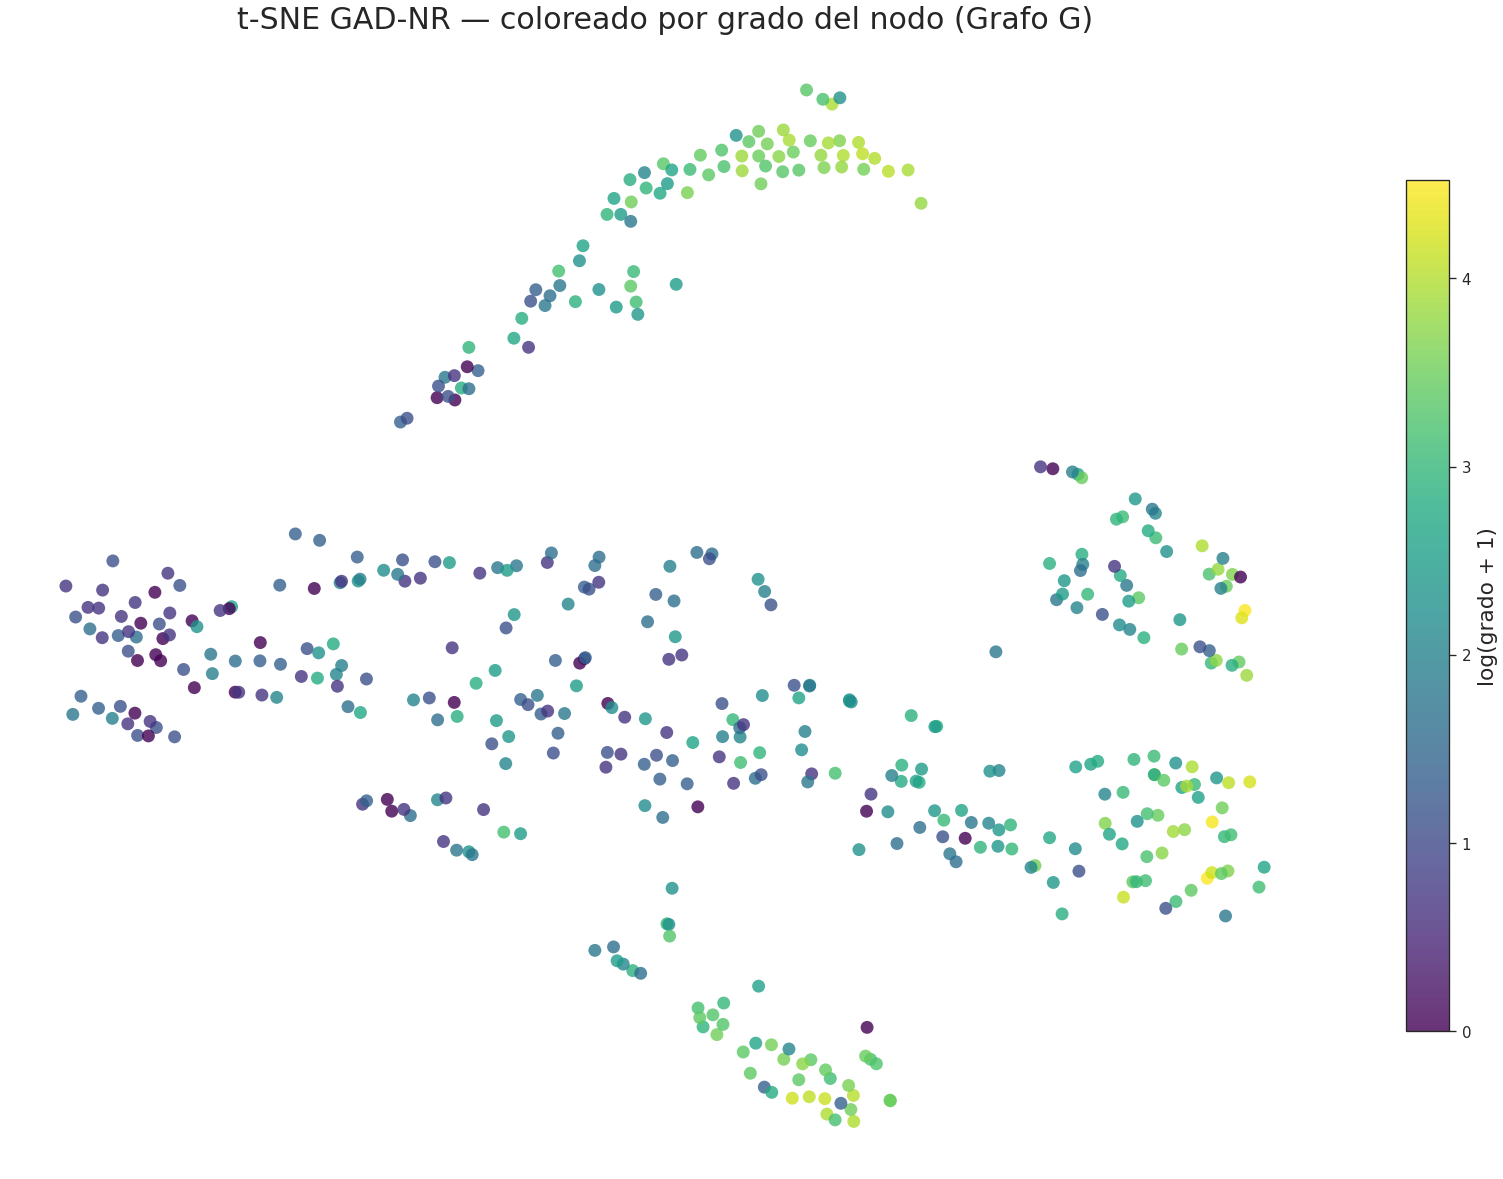

In [32]:
def plot_tsne_panel(tsne_coords, scores_df, model_name, type_col, score_col,
                    figname_prefix):
    """Genera las tres vistas t-SNE para un modelo: tipo, score, grado."""
    # Fuentes escaladas para figuras (14, 10)
    FONT_TSNE = {
        'title':      18,
        'axis_label': 13,
        'legend':     12,
        'annotation': 10,
    }

    def remove_all_spines(ax):
        for spine in ax.spines.values():
            spine.set_visible(False)

    # ── Vista 1: tipo de anomalía ────────────────────────────────────────
    style_by_type = {
        'Normal':      (color_map['Normal'],      0.35,  30),
        'Estructural': (color_map['Estructural'], 0.90, 100),
        'Atributo':    (color_map['Atributo'],    0.90, 100),
        'Mixta':       (color_map['Mixta'],       1.00, 180),
    }

    fig, ax = plt.subplots(figsize=(14, 10))
    for atype in ['Normal', 'Estructural', 'Atributo', 'Mixta']:
        mask = scores_df[type_col] == atype
        color, alpha, size = style_by_type[atype]
        zorder = 1 if atype == 'Normal' else 3
        ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                   s=size, alpha=alpha, color=color,
                   label=f'{atype} ({mask.sum()})',
                   zorder=zorder, edgecolors='none')

    ax.set_title(f't-SNE {model_name} — coloreado por tipo de anomalía (Grafo G)',
                 fontsize=FONT_TSNE['title'])
    ax.legend(title='Tipo', fontsize=FONT_TSNE['legend'], frameon=False,
              title_fontsize=FONT_TSNE['legend'] + 2,
              markerscale=1.5, loc='upper right')
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_type_G.png')
    plt.show()

    # ── Vista 2: score compuesto (gradiente continuo) ────────────────────
    anom_mask = scores_df[type_col] != 'Normal'
    normal_mask = ~anom_mask
    vmin_val = scores_df.loc[anom_mask, score_col].quantile(0.20)
    vmax_val = scores_df.loc[anom_mask, score_col].quantile(0.98)

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(tsne_coords[normal_mask, 0], tsne_coords[normal_mask, 1],
               s=30, alpha=0.25, color=PALETTE['neutral'], zorder=1)

    sc = ax.scatter(
        tsne_coords[anom_mask, 0], tsne_coords[anom_mask, 1],
        c=scores_df.loc[anom_mask, score_col],
        s=120, alpha=0.90, cmap=CMAP_HEAT, zorder=3,
        vmin=vmin_val,
        vmax=vmax_val,
        edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label(f'Score compuesto {model_name}', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — intensidad del score en nodos anómalos (Grafo G)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_score_G.png')
    plt.show()

    # ── Vista 3: grado del nodo (escala log) ─────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 10))
    sc = ax.scatter(
        tsne_coords[:, 0], tsne_coords[:, 1],
        c=np.log1p(scores_df['degree']),
        s=60, alpha=0.80, cmap=CMAP_SEQ, edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label('log(grado + 1)', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — coloreado por grado del nodo (Grafo G)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_degree_G.png')
    plt.show()


# t-SNE DOMINANT
plot_tsne_panel(
    tsne_coords=tsne_dom,
    scores_df=scores_df,
    model_name='DOMINANT',
    type_col='type_dom',
    score_col='dom_combined',
    figname_prefix='06_dominant',
)

# t-SNE GAD-NR
plot_tsne_panel(
    tsne_coords=tsne_gadnr,
    scores_df=scores_df,
    model_name='GAD-NR',
    type_col='type_gadnr',
    score_col='gadnr_score',
    figname_prefix='06_gadnr',
)


## 9. Guardado de resultados


In [33]:
cols_export = [
    'idx', 'group_id', 'name', 'category_name', 'num_members', 'organizer_id', 'degree',
    # Sub-scores brutos
    'dom_struct', 'dom_attr', 'dom_combined',
    'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score',
    # Percentiles
    'pct_dom_struct', 'pct_dom_attr',
    'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h',
    # Tipologías
    'type_dom', 'type_gadnr',
]

scores_export = scores_df[[c for c in cols_export if c in scores_df.columns]]
scores_export.to_csv(os.path.join(RESULTS_PATH, 'scores_G.csv'), index=False)

print(f'Guardado : {RESULTS_PATH}scores_G.csv')
print(f'Shape    : {scores_export.shape}')

# Embeddings finales y coordenadas t-SNE
np.savez(
    os.path.join(RESULTS_PATH, 'embeddings_G.npz'),
    emb_dom=emb_dom,
    emb_gadnr=emb_gadnr,
    tsne_dom=tsne_dom,
    tsne_gadnr=tsne_gadnr,
    group_ids=np.array(group_ids),
)
print(f'Guardado : {RESULTS_PATH}embeddings_G.npz')


Guardado : ../data/results/scores_G.csv
Shape    : (456, 21)
Guardado : ../data/results/embeddings_G.npz


## Resumen del notebook

Sección pendiente de completar tras la ejecución del notebook. Los puntos a documentar son:

1. Convergencia del entrenamiento de DOMINANT y rangos de `dom_struct`/`dom_attr`.
2. Convergencia de GAD-NR, rangos de los tres sub-scores y **lambdas finales tras curriculum**
   (comparar con los del grafo M: 0.01 / 7.6 / 2.4·10⁻⁵).
3. Correlación Spearman y solapamiento top-50 entre `dom_struct` y `gadnr_deg`.
4. Correlación Spearman y solapamiento top-50 entre `dom_attr` y `gadnr_feat`.
5. Estadísticos descriptivos del score compuesto en ambos modelos.
6. Número de grupos joint-type puros y caracterización (grado, categoría).
7. Validación de los candidatos del EDA — qué señales detectan a cada uno.
8. Análisis visual del t-SNE — ¿separa GAD-NR mejor las tipologías que en el grafo M?

Los resultados quedarán en `scores_G.csv` (456 nodos × 21 columnas) y `embeddings_G.npz`.
